In [1]:
# Implement EGB
def compute_egb_coreset(P, A, epsilon, c=10.0):
    """
    Computes a (k, epsilon)-coreset for k-means using the Exponential Grid-Based algorithm.

    Parameters:
    P : ndarray of shape (n, d) - The original dataset.
    A : ndarray of shape (m, d) - The initial centers (e.g., from kmeans++).
    epsilon : float - The error tolerance parameter.
    c : float - The constant approximation factor of the initial centers A.

    Returns:
    coreset_points : ndarray - The representative points of the coreset.
    coreset_weights : ndarray - The weights associated with each representative.
    """
    n, d = P.shape
    # m = A.shape[0]

    # --- STEP 1 & 2: Assignments and Average Radius Estimate ---
    # Calculate squared euclidean distances from all points in P to all centers in A
    dist_sq = distance.cdist(P, A, 'sqeuclidean')

    # Find the nearest center index for each point
    nearest_center_idx = np.argmin(dist_sq, axis=1)

    # Get the squared distance to the assigned center
    min_dist_sq = dist_sq[np.arange(n), nearest_center_idx]

    # mu_A(P) is the total k-means cost using centers A
    mu_A_P = np.sum(min_dist_sq)

    # R is the lower bound estimate of the average mean radius
    R = np.sqrt(mu_A_P / (c * n))

    # Edge case: if all points sit exactly on the centers, cost is 0
    if R == 0:
        return P, np.ones(n)

    # --- STEP 3: Determine the Exponential Shell (j) ---
    # Calculate the L-infinity distance (Chebyshev) to find which axis-parallel square the point falls into
    diffs = np.abs(P - A[nearest_center_idx])
    L_inf_dists = np.max(diffs, axis=1)  # |p-x|infinity

    # j = ceil(1 + log2(L_inf_dists / R)) calculates the shell index
    with np.errstate(divide='ignore'):
        # ASK: safety buffer
        # j_vals = np.ceil(1 + np.log2(L_inf_dists / R))
        # j_vals = np.ceil(np.log2(L_inf_dists / R))

        # 1. Calculate the exact theoretical shell index
        # FIXING THIS: AND GOING TO RERUN THE RESULTS:
        exact_j = np.ceil(np.log2(L_inf_dists / R))

        # 2. If a point is inside the inner ball (distance <= R), its exact_j will be <= 0.
        # np.maximum forces those negative/zero values up to 1, leaving the outer shells perfectly intact!
        j_vals = np.maximum(1, exact_j)

    # Points inside Q_{i,0} have j=0
    # j_vals = np.clip(j_vals, 0, np.inf).astype(int)

    # Maximum shell index M = ceil(2 * log2(cn))
    # M = int(np.ceil((d / 2.0) * np.log2(c * n)))
    M = int(np.ceil(2.0 * np.log2(c * n)))
    j_vals = np.clip(j_vals, 0, M)

    # --- STEP 4: Compute Grid Size (r_j) and Snap Points ---
    # r_j = epsilon * R * 2^j / (10 * c * d)
    r_j = (epsilon * R * (2.0 ** j_vals)) / (10.0 * c * d)

    # Divide continuous coordinates by r_j and floor them to snap to discrete grid cells
    # cell_coords = np.floor(P / r_j[:, None]).astype(int)
    cell_coords = np.floor((P - A[nearest_center_idx]) / r_j[:, None]).astype(int)

    # --- STEP 5: Extract Representatives and Weights ---
    # Create a unique signature for each point's grid cell: (center_idx, shell_j, grid_x, grid_y, ...)
    signatures = np.hstack((nearest_center_idx[:, None], j_vals[:, None], cell_coords))

    # Find unique cells, grab the index of the first point found there, and count how many points share it
    unique_sigs, indices, counts = np.unique(signatures, axis=0, return_index=True, return_counts=True)

    # The representative points are simply the original points at those unique indices
    coreset_points = P[indices]
    coreset_weights = counts

    return coreset_points, coreset_weights

FINAL DATASETS & IMAGES BELOW:

## Dataset 1: Spotify (4D)
**~83K rows, features: energy, valence, danceability, acousticness**

In [5]:
!pip install scikit-learn

  Using cached joblib-1.5.3-py3-none-any.whl.metadata (5.5 kB)
  Using cached threadpoolctl-3.6.0-py3-none-any.whl.metadata (13 kB)
   ---------------------------------------- 0.0/8.0 MB ? eta -:--:--
   ------- -------------------------------- 1.6/8.0 MB 14.1 MB/s eta 0:00:01
   ------------------------------ --------- 6.0/8.0 MB 18.5 MB/s eta 0:00:01
   ---------------------------------------- 8.0/8.0 MB 19.1 MB/s  0:00:00
Using cached joblib-1.5.3-py3-none-any.whl (309 kB)
Using cached threadpoolctl-3.6.0-py3-none-any.whl (18 kB)

   ------------- -------------------------- 1/3 [joblib]
   -------------------------- ------------- 2/3 [scikit-learn]
   -------------------------- ------------- 2/3 [scikit-learn]
   -------------------------- ------------- 2/3 [scikit-learn]
   -------------------------- ------------- 2/3 [scikit-learn]
   -------------------------- ------------- 2/3 [scikit-learn]
   -------------------------- ------------- 2/3 [scikit-learn]
   ----------------------


[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Shape: (114000, 6)
Columns: ['danceability', 'energy', 'speechiness', 'acousticness', 'instrumentalness', 'valence']
   danceability  energy  speechiness  acousticness  instrumentalness  valence
0         0.676  0.4610       0.1430        0.0322          0.000001    0.715
1         0.420  0.1660       0.0763        0.9240          0.000006    0.267
2         0.438  0.3590       0.0557        0.2100          0.000000    0.120
3         0.266  0.0596       0.0363        0.9050          0.000071    0.143
4         0.618  0.4430       0.0526        0.4690          0.000000    0.167
        danceability         energy    speechiness   acousticness  \
count  114000.000000  114000.000000  114000.000000  114000.000000   
mean        0.566800       0.641383       0.084652       0.314910   
std         0.173542       0.251529       0.105732       0.332523   
min         0.000000       0.000000       0.000000       0.000000   
25%         0.456000       0.472000       0.035900       0.016900   
5

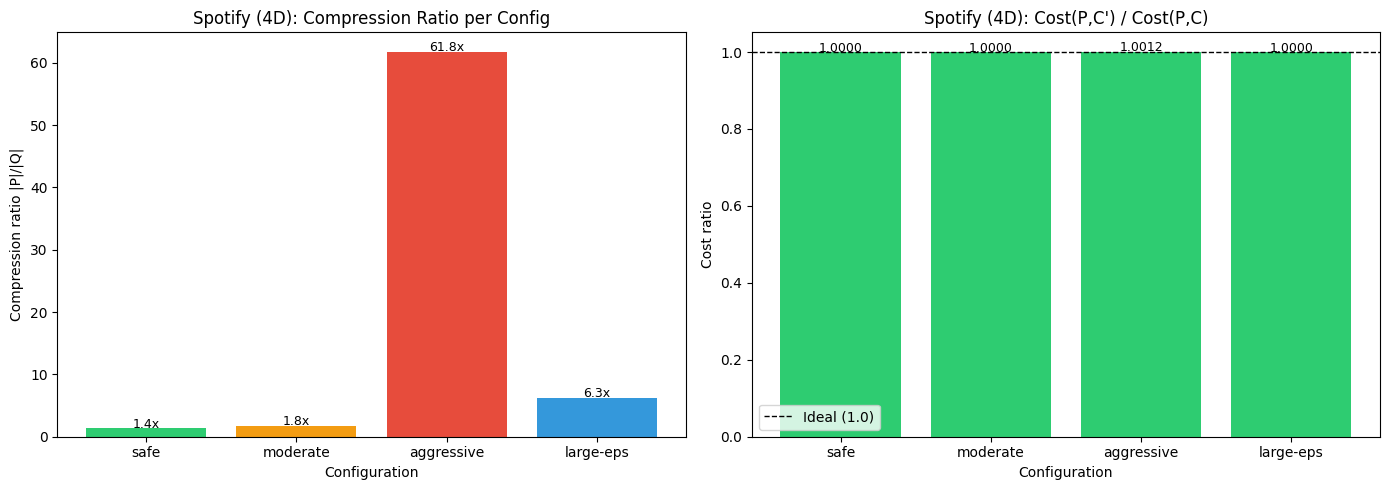


Spotify complete.


In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import time
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score
from scipy.spatial import distance

INITIAL_K_FACTOR = 3

def kmeans_cost(X, centers, weights=None):
    dists = np.min(np.sum((X[:, None, :] - centers[None, :, :]) ** 2, axis=2), axis=1)
    if weights is not None:
        return np.sum(weights * dists)
    return np.sum(dists)

# --- Load ---
df = pd.read_csv("Final/spotify.csv")
print(f"Shape: {df.shape}")
print(f"Columns: {list(df.columns)}")
print(df.head())
print(df.describe())

# --- Select 4 features ---
feature_cols = ['energy', 'valence', 'danceability', 'acousticness']
X_raw = df[feature_cols].values.astype(float)
print(f"\nNaN count: {np.isnan(X_raw).sum()}")
X_raw = X_raw[~np.isnan(X_raw).any(axis=1)]
P = StandardScaler().fit_transform(X_raw)
n, d = P.shape
print(f"After cleaning: n={n}, d={d}")

# --- Determine k via silhouette ---
print("\n--- Silhouette search for k ---")
best_k, best_sil = 2, -1
for k_try in [2, 3, 4, 6, 8, 10, 12, 16, 24, 32]:
    km = KMeans(n_clusters=k_try, n_init=5, max_iter=200, random_state=42)
    labels = km.fit_predict(P)
    sil = silhouette_score(P, labels, sample_size=min(10000, n))
    print(f"  k={k_try}: silhouette={sil:.4f}")
    if sil > best_sil:
        best_k, best_sil = k_try, sil
k = best_k
print(f"  => Using k={k} (silhouette={best_sil:.4f})")

# --- Full k-means ---
print(f"\nRunning full k-means (k={k}, n={n:,})...")
t0 = time.time()
km_full = KMeans(n_clusters=k, n_init=10, max_iter=300, random_state=42)
km_full.fit(P)
t_full = time.time() - t0
C = km_full.cluster_centers_
cost_P_C = kmeans_cost(P, C)
print(f"Full k-means cost(P,C) = {cost_P_C:.2f}, time={t_full:.1f}s")

# --- EGB configs ---
configs = [
    {"epsilon": 0.5, "c": 3.0,  "label": "safe"},
    {"epsilon": 1.0, "c": 0.6,  "label": "moderate"},
    {"epsilon": 2.0, "c": 0.3,  "label": "aggressive"},
    {"epsilon": 5.0, "c": 1.0,  "label": "large-eps"},
]

results = []
h2 = "Q,C'/P,C'"
h3 = "P,C'/P,C"
print(f"\n{'Config':<20} {'|Q|':>8} {'|P|/|Q|':>10} {'Q,C/P,C':>10} {h2:>12} {h3:>10}")
print("-" * 75)

for cfg in configs:
    eps, c_val, label = cfg["epsilon"], cfg["c"], cfg["label"]
    initial_k = min(k * INITIAL_K_FACTOR, n - 1)
    A = KMeans(n_clusters=initial_k, n_init=3, max_iter=50, random_state=42).fit(P).cluster_centers_

    Q, w_Q = compute_egb_coreset(P, A, epsilon=eps, c=c_val)
    q_size = len(Q)
    compression = n / q_size

    cost_Q_C = kmeans_cost(Q, C, weights=w_Q)

    km_q = KMeans(n_clusters=k, n_init=10, max_iter=300, random_state=42)
    km_q.fit(Q, sample_weight=w_Q)
    C_prime = km_q.cluster_centers_

    cost_Q_Cp = kmeans_cost(Q, C_prime, weights=w_Q)
    cost_P_Cp = kmeans_cost(P, C_prime)

    r1 = cost_Q_C / cost_P_C
    r2 = cost_Q_Cp / cost_P_Cp
    r3 = cost_P_Cp / cost_P_C

    print(f"{label:<20} {q_size:>8,} {compression:>10.1f}x {r1:>10.6f} {r2:>12.6f} {r3:>10.6f}")
    results.append({"label": label, "q_size": q_size, "compression": compression,
                     "r1": r1, "r2": r2, "r3": r3})

# --- Plots ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

labels_list = [r["label"] for r in results]
compressions = [r["compression"] for r in results]
r3_vals = [r["r3"] for r in results]

axes[0].bar(labels_list, compressions, color=['#2ecc71', '#f39c12', '#e74c3c', '#3498db'])
axes[0].set_ylabel("Compression ratio |P|/|Q|")
axes[0].set_title("Spotify (4D): Compression Ratio per Config")
axes[0].set_xlabel("Configuration")
for i, v in enumerate(compressions):
    axes[0].text(i, v + 0.1, f"{v:.1f}x", ha='center', fontsize=9)

colors = ['#2ecc71' if v < 1.02 else '#f39c12' if v < 1.05 else '#e74c3c' for v in r3_vals]
axes[1].bar(labels_list, r3_vals, color=colors)
axes[1].axhline(y=1.0, color='black', linestyle='--', linewidth=1, label='Ideal (1.0)')
axes[1].set_ylabel("Cost ratio")
h3_title = "Cost(P,C') / Cost(P,C)"
axes[1].set_title(f"Spotify (4D): {h3_title}")
axes[1].set_xlabel("Configuration")
axes[1].legend()
for i, v in enumerate(r3_vals):
    axes[1].text(i, v + 0.001, f"{v:.4f}", ha='center', fontsize=9)

plt.tight_layout()
plt.savefig("Final/spotify_results.png", dpi=150, bbox_inches='tight')
plt.show()
print("\nSpotify complete.")


In [ ]:
# --- Full epsilon x c grid + reference-format plots for Spotify (4D) ---
# Uses `P`, `C`, `cost_P_C`, `n`, `k` from the cell above

import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

INITIAL_K_FACTOR = 3

def kmeans_cost(X, centers, weights=None):
    dists = np.min(np.sum((X[:, None, :] - centers[None, :, :]) ** 2, axis=2), axis=1)
    if weights is not None:
        return np.sum(weights * dists)
    return np.sum(dists)

# --- Full parameter grid ---
epsilons = [0.01, 0.10, 0.30, 0.50, 1.00, 2.00, 5.00, 7.00]
c_values = [0.01, 0.10, 0.20, 0.30, 0.60, 1.00, 3.00, 5.00]

# Compute initial centers A once (reused across all configs)
initial_k = min(k * INITIAL_K_FACTOR, n - 1)
A = KMeans(n_clusters=initial_k, n_init=3, max_iter=50, random_state=42).fit(P).cluster_centers_

# Run the full grid
grid_results = {}
h1 = "Q,C/P,C"
h2_hdr = "Q,C'/P,C'"
h3_hdr = "P,C'/P,C"

print(f"Spotify (4D) — Full epsilon x c parameter grid")
print(f"|P|={n:,}   k={k}   d={P.shape[1]}")
print()
print(f"{'eps':>8} | {'c':>8} | {'|Q|':>10} | {'Compress':>10} | {h3_hdr:>12} | {'Status'}")
print("-" * 75)

for eps in epsilons:
    for c_val in c_values:
        Q, w_Q = compute_egb_coreset(P, A, epsilon=eps, c=c_val)
        q_size = len(Q)
        compression = n / q_size

        cost_Q_C = kmeans_cost(Q, C, weights=w_Q)

        km_q = KMeans(n_clusters=k, n_init=10, max_iter=300, random_state=42)
        km_q.fit(Q, sample_weight=w_Q)
        C_prime = km_q.cluster_centers_

        cost_Q_Cp = kmeans_cost(Q, C_prime, weights=w_Q)
        cost_P_Cp = kmeans_cost(P, C_prime)

        r1 = cost_Q_C / cost_P_C
        r2 = cost_Q_Cp / cost_P_Cp if cost_P_Cp > 0 else float('nan')
        r3 = cost_P_Cp / cost_P_C

        # Status label
        if c_val < 1.0:
            status = "broken"
        else:
            status = "safe"

        check = "+" if r3 < 1.05 else "-"
        print(f"{eps:>8.2f} | {c_val:>8.2f} | {q_size:>10,} | {compression:>9.1f}x | {r3:>12.6f} {check} | {status}")

        grid_results[(eps, c_val)] = {
            "q_size": q_size, "compression": compression,
            "r1": r1, "r2": r2, "r3": r3
        }

# --- Generate reference-format plots per fixed c ---
for c_val in c_values:
    eps_list = epsilons
    q_sizes = [grid_results[(e, c_val)]["q_size"] for e in eps_list]
    compressions = [grid_results[(e, c_val)]["compression"] for e in eps_list]
    r1_vals = [grid_results[(e, c_val)]["r1"] for e in eps_list]
    r2_vals = [grid_results[(e, c_val)]["r2"] for e in eps_list]
    r3_vals = [grid_results[(e, c_val)]["r3"] for e in eps_list]

    x_positions = np.arange(len(eps_list))

    # --- Plot 1: Cost ratios line plot (image.png style) ---
    fig, ax = plt.subplots(figsize=(10, 5))

    ax.plot(x_positions, r1_vals, 'o-', color='#1f77b4', label='Cost(Q,C) / Cost(P,C)', linewidth=2, markersize=8)
    qcp_label = "Cost(Q,C') / Cost(P,C')"
    pcp_label = "Cost(P,C') / Cost(P,C)"
    ax.plot(x_positions, r2_vals, 's-', color='#ff7f0e', label=qcp_label, linewidth=2, markersize=8)
    ax.plot(x_positions, r3_vals, '^-', color='#2ca02c', label=pcp_label, linewidth=2, markersize=8)
    ax.axhline(y=1.0, color='black', linestyle='--', linewidth=1)

    xtick_labels = []
    for i_e, e in enumerate(eps_list):
        qs = q_sizes[i_e]
        xtick_labels.append(f"eps={e}\n|Q|={qs:,}")
    ax.set_xticks(x_positions)
    ax.set_xticklabels(xtick_labels, fontsize=8)
    ax.set_xlabel("epsilon and coreset size", fontsize=11)
    ax.set_ylabel("ratio value", fontsize=11)
    ax.set_title(f"Cost ratios across epsilon for fixed c — Spotify (4D)", fontsize=13)
    ax.legend(loc='upper left', fontsize=9)
    ax.text(0.01, 0.97, f"|P|={n:,}    c={c_val}",
            transform=ax.transAxes, fontsize=9, verticalalignment='top', fontfamily='monospace')

    plt.tight_layout()
    plt.savefig(f"Final/spotify_cost_ratios_c{c_val}.png", dpi=150, bbox_inches='tight')
    plt.show()

    # --- Plot 2: Dual-axis coreset size + compression (image (1).png style) ---
    fig, ax1 = plt.subplots(figsize=(10, 5))

    ax1.plot(x_positions, q_sizes, 'o-', color='#1f77b4', linewidth=2, markersize=8)
    ax1.set_yscale('log')
    ax1.set_ylabel("coreset size |Q|", color='#1f77b4', fontsize=11)
    ax1.tick_params(axis='y', labelcolor='#1f77b4')

    ax2 = ax1.twinx()
    ax2.plot(x_positions, compressions, 's-', color='#d62728', linewidth=2, markersize=8)
    ax2.set_yscale('log')
    ax2.set_ylabel("inverse compression |P| / |Q|", color='#d62728', fontsize=11)
    ax2.tick_params(axis='y', labelcolor='#d62728')

    xtick_labels2 = [f"{e}" for e in eps_list]
    ax1.set_xticks(x_positions)
    ax1.set_xticklabels(xtick_labels2, fontsize=9)
    ax1.set_xlabel("epsilon", fontsize=11)
    ax1.set_title(f"Fixed-c sweep: coreset size collapse as epsilon grows — Spotify (4D) (c={c_val})", fontsize=12)

    plt.tight_layout()
    plt.savefig(f"Final/spotify_size_compress_c{c_val}.png", dpi=150, bbox_inches='tight')
    plt.show()

print(f"\nSpotify (4D) grid complete: {len(epsilons)} x {len(c_values)} = {len(epsilons)*len(c_values)} configs")


## Dataset 2: Citibike (2D)
**~999K rows, features: longitude, latitude (NYC)**

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import time
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score
from scipy.spatial import distance

INITIAL_K_FACTOR = 3

def kmeans_cost(X, centers, weights=None):
    dists = np.min(np.sum((X[:, None, :] - centers[None, :, :]) ** 2, axis=2), axis=1)
    if weights is not None:
        return np.sum(weights * dists)
    return np.sum(dists)

# --- Load ---
df = pd.read_csv("Final/boris_citibike_2d.csv")
print(f"Shape: {df.shape}")
print(f"Columns: {list(df.columns)}")
print(df.head())
print(df.describe())

# --- Select features ---
X_raw = df[['longitude', 'latitude']].values.astype(float)
print(f"\nNaN count: {np.isnan(X_raw).sum()}")
X_raw = X_raw[~np.isnan(X_raw).any(axis=1)]

# --- Check coordinate ranges and filter outliers ---
print(f"\nLongitude range: [{X_raw[:,0].min():.4f}, {X_raw[:,0].max():.4f}]")
print(f"Latitude range:  [{X_raw[:,1].min():.4f}, {X_raw[:,1].max():.4f}]")

# NYC bounding box (generous)
mask = (X_raw[:,0] >= -74.3) & (X_raw[:,0] <= -73.7) & \
       (X_raw[:,1] >= 40.5) & (X_raw[:,1] <= 40.95)
X_raw = X_raw[mask]
print(f"After NYC filter: {len(X_raw):,} rows")

P_raw = X_raw.copy()
P = StandardScaler().fit_transform(X_raw)
n, d = P.shape
print(f"Final: n={n:,}, d={d}")

# --- Determine k via silhouette ---
print()
print("--- Silhouette search for k ---")
best_k, best_sil = 2, -1
for k_try in [2, 3, 4, 6, 8, 10, 12, 16, 24, 32]:
    km = KMeans(n_clusters=k_try, n_init=5, max_iter=200, random_state=42)
    labels = km.fit_predict(P)
    sil = silhouette_score(P, labels, sample_size=min(10000, n))
    print(f"  k={k_try}: silhouette={sil:.4f}")
    if sil > best_sil:
        best_k, best_sil = k_try, sil
k = best_k
print(f"  => Using k={k} (silhouette={best_sil:.4f})")

# --- Full k-means ---
print(f"\nRunning full k-means (k={k}, n={n:,})...")
t0 = time.time()
km_full = KMeans(n_clusters=k, n_init=10, max_iter=300, random_state=42)
km_full.fit(P)
t_full = time.time() - t0
C = km_full.cluster_centers_
cost_P_C = kmeans_cost(P, C)
print(f"Full k-means cost(P,C) = {cost_P_C:.2f}, time={t_full:.1f}s")

# --- Identify center locations ---
scaler = StandardScaler().fit(P_raw)
C_geo = scaler.inverse_transform(C)
print(f"\nCluster centers (geographic):")
for i, (lon, lat) in enumerate(C_geo):
    print(f"  Center {i}: ({lat:.4f}, {lon:.4f})")

# --- EGB configs ---
configs = [
    {"epsilon": 0.5, "c": 3.0,  "label": "safe"},
    {"epsilon": 1.0, "c": 0.6,  "label": "moderate"},
    {"epsilon": 2.0, "c": 0.3,  "label": "aggressive"},
    {"epsilon": 5.0, "c": 1.0,  "label": "large-eps"},
]

results = []
best_cfg_idx = -1
best_compression_under_105 = 0

h2 = "Q,C'/P,C'"
h3 = "P,C'/P,C"
print(f"\n{'Config':<20} {'|Q|':>8} {'|P|/|Q|':>10} {'Q,C/P,C':>10} {h2:>12} {h3:>10} {'EGB(s)':>8} {'KM(s)':>8}")
print("-" * 95)

for ci, cfg in enumerate(configs):
    eps, c_val, label = cfg["epsilon"], cfg["c"], cfg["label"]
    initial_k = min(k * INITIAL_K_FACTOR, n - 1)

    t0 = time.time()
    A = KMeans(n_clusters=initial_k, n_init=3, max_iter=50, random_state=42).fit(P).cluster_centers_
    Q, w_Q = compute_egb_coreset(P, A, epsilon=eps, c=c_val)
    t_egb = time.time() - t0

    q_size = len(Q)
    compression = n / q_size
    cost_Q_C = kmeans_cost(Q, C, weights=w_Q)

    t0 = time.time()
    km_q = KMeans(n_clusters=k, n_init=10, max_iter=300, random_state=42)
    km_q.fit(Q, sample_weight=w_Q)
    t_km = time.time() - t0
    C_prime = km_q.cluster_centers_

    cost_Q_Cp = kmeans_cost(Q, C_prime, weights=w_Q)
    cost_P_Cp = kmeans_cost(P, C_prime)

    r1 = cost_Q_C / cost_P_C
    r2 = cost_Q_Cp / cost_P_Cp
    r3 = cost_P_Cp / cost_P_C

    print(f"{label:<20} {q_size:>8,} {compression:>10.1f}x {r1:>10.6f} {r2:>12.6f} {r3:>10.6f} {t_egb:>8.1f} {t_km:>8.1f}")

    # Identify coreset-derived center locations
    C_prime_geo = scaler.inverse_transform(C_prime)
    print(f"  Coreset centers ({label}):")
    for j, (lon, lat) in enumerate(C_prime_geo):
        # Match to nearest full-kmeans center (centers aren't ordered the same)
        dists_to_full = np.sqrt(np.sum((C - C_prime[j])**2, axis=1))
        nearest_full = np.argmin(dists_to_full)
        shift = dists_to_full[nearest_full]
        print(f"    Center {j}: ({lat:.4f}, {lon:.4f}), nearest full center={nearest_full}, shift={shift:.4f}")

    results.append({"label": label, "q_size": q_size, "compression": compression,
                     "r1": r1, "r2": r2, "r3": r3, "C_prime": C_prime,
                     "Q": Q, "w_Q": w_Q})

    if r3 < 1.05 and compression > best_compression_under_105:
        best_compression_under_105 = compression
        best_cfg_idx = ci

# --- Bar plots ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

labels_list = [r["label"] for r in results]
compressions = [r["compression"] for r in results]
r3_vals = [r["r3"] for r in results]

axes[0].bar(labels_list, compressions, color=['#2ecc71', '#f39c12', '#e74c3c', '#3498db'])
axes[0].set_ylabel("Compression ratio |P|/|Q|")
axes[0].set_title("Citibike (2D): Compression Ratio per Config")
axes[0].set_xlabel("Configuration")
for i, v in enumerate(compressions):
    axes[0].text(i, v + 0.1, f"{v:.1f}x", ha='center', fontsize=9)

colors = ['#2ecc71' if v < 1.02 else '#f39c12' if v < 1.05 else '#e74c3c' for v in r3_vals]
axes[1].bar(labels_list, r3_vals, color=colors)
axes[1].axhline(y=1.0, color='black', linestyle='--', linewidth=1, label='Ideal (1.0)')
axes[1].set_ylabel("Cost ratio")
h3_title = "Cost(P,C') / Cost(P,C)"
axes[1].set_title(f"Citibike (2D): {h3_title}")
axes[1].set_xlabel("Configuration")
axes[1].legend()
for i, v in enumerate(r3_vals):
    axes[1].text(i, v + 0.001, f"{v:.4f}", ha='center', fontsize=9)

plt.tight_layout()
plt.savefig("Final/citibike_results.png", dpi=150, bbox_inches='tight')
plt.show()

# --- Map comparison ---
if best_cfg_idx >= 0:
    best = results[best_cfg_idx]
else:
    best = results[0]

fig, axes = plt.subplots(1, 2, figsize=(16, 8))

# Subsample for plotting
plot_n = min(100000, n)
idx_plot = np.random.RandomState(42).choice(n, plot_n, replace=False)
P_plot = P_raw[idx_plot]

labels_full = km_full.predict(P[idx_plot])
labels_egb = np.argmin(np.sum((P[idx_plot, None, :] - best["C_prime"][None, :, :]) ** 2, axis=2), axis=1)

cmap = plt.cm.tab10

axes[0].scatter(P_plot[:, 0], P_plot[:, 1], c=labels_full, cmap=cmap, s=0.5, alpha=0.3)
C_full_geo = scaler.inverse_transform(C)
axes[0].scatter(C_full_geo[:, 0], C_full_geo[:, 1], c='red', marker='*', s=200, edgecolors='black', linewidths=1, zorder=5)
axes[0].set_title(f"Full k-means (k={k}, n={n:,})")
axes[0].set_xlabel("Longitude")
axes[0].set_ylabel("Latitude")

axes[1].scatter(P_plot[:, 0], P_plot[:, 1], c=labels_egb, cmap=cmap, s=0.5, alpha=0.3)
C_prime_geo = scaler.inverse_transform(best["C_prime"])
axes[1].scatter(C_prime_geo[:, 0], C_prime_geo[:, 1], c='red', marker='*', s=200, edgecolors='black', linewidths=1, zorder=5)
best_label = results[best_cfg_idx if best_cfg_idx >= 0 else 0]["label"]
best_comp = results[best_cfg_idx if best_cfg_idx >= 0 else 0]["compression"]
axes[1].set_title(f"EGB ({best_label}, {best_comp:.1f}x compression)")
axes[1].set_xlabel("Longitude")
axes[1].set_ylabel("Latitude")

plt.suptitle("Citibike NYC: Full k-means vs EGB Coreset", fontsize=14)
plt.tight_layout()
plt.savefig("Final/citibike_map.png", dpi=150, bbox_inches='tight')
plt.show()

print("\nCitibike complete.")


In [ ]:
# --- Full epsilon x c grid + reference-format plots for Citibike (2D) ---
# Uses `P`, `C`, `cost_P_C`, `n`, `k` from the cell above

import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

INITIAL_K_FACTOR = 3

def kmeans_cost(X, centers, weights=None):
    dists = np.min(np.sum((X[:, None, :] - centers[None, :, :]) ** 2, axis=2), axis=1)
    if weights is not None:
        return np.sum(weights * dists)
    return np.sum(dists)

# --- Full parameter grid ---
epsilons = [0.01, 0.10, 0.30, 0.50, 1.00, 2.00, 5.00, 7.00]
c_values = [0.01, 0.10, 0.20, 0.30, 0.60, 1.00, 3.00, 5.00]

# Compute initial centers A once (reused across all configs)
initial_k = min(k * INITIAL_K_FACTOR, n - 1)
A = KMeans(n_clusters=initial_k, n_init=3, max_iter=50, random_state=42).fit(P).cluster_centers_

# Run the full grid
grid_results = {}
h1 = "Q,C/P,C"
h2_hdr = "Q,C'/P,C'"
h3_hdr = "P,C'/P,C"

print(f"Citibike (2D) — Full epsilon x c parameter grid")
print(f"|P|={n:,}   k={k}   d={P.shape[1]}")
print()
print(f"{'eps':>8} | {'c':>8} | {'|Q|':>10} | {'Compress':>10} | {h3_hdr:>12} | {'Status'}")
print("-" * 75)

for eps in epsilons:
    for c_val in c_values:
        Q, w_Q = compute_egb_coreset(P, A, epsilon=eps, c=c_val)
        q_size = len(Q)
        compression = n / q_size

        cost_Q_C = kmeans_cost(Q, C, weights=w_Q)

        km_q = KMeans(n_clusters=k, n_init=10, max_iter=300, random_state=42)
        km_q.fit(Q, sample_weight=w_Q)
        C_prime = km_q.cluster_centers_

        cost_Q_Cp = kmeans_cost(Q, C_prime, weights=w_Q)
        cost_P_Cp = kmeans_cost(P, C_prime)

        r1 = cost_Q_C / cost_P_C
        r2 = cost_Q_Cp / cost_P_Cp if cost_P_Cp > 0 else float('nan')
        r3 = cost_P_Cp / cost_P_C

        # Status label
        if c_val < 1.0:
            status = "broken"
        else:
            status = "safe"

        check = "+" if r3 < 1.05 else "-"
        print(f"{eps:>8.2f} | {c_val:>8.2f} | {q_size:>10,} | {compression:>9.1f}x | {r3:>12.6f} {check} | {status}")

        grid_results[(eps, c_val)] = {
            "q_size": q_size, "compression": compression,
            "r1": r1, "r2": r2, "r3": r3
        }

# --- Generate reference-format plots per fixed c ---
for c_val in c_values:
    eps_list = epsilons
    q_sizes = [grid_results[(e, c_val)]["q_size"] for e in eps_list]
    compressions = [grid_results[(e, c_val)]["compression"] for e in eps_list]
    r1_vals = [grid_results[(e, c_val)]["r1"] for e in eps_list]
    r2_vals = [grid_results[(e, c_val)]["r2"] for e in eps_list]
    r3_vals = [grid_results[(e, c_val)]["r3"] for e in eps_list]

    x_positions = np.arange(len(eps_list))

    # --- Plot 1: Cost ratios line plot (image.png style) ---
    fig, ax = plt.subplots(figsize=(10, 5))

    ax.plot(x_positions, r1_vals, 'o-', color='#1f77b4', label='Cost(Q,C) / Cost(P,C)', linewidth=2, markersize=8)
    qcp_label = "Cost(Q,C') / Cost(P,C')"
    pcp_label = "Cost(P,C') / Cost(P,C)"
    ax.plot(x_positions, r2_vals, 's-', color='#ff7f0e', label=qcp_label, linewidth=2, markersize=8)
    ax.plot(x_positions, r3_vals, '^-', color='#2ca02c', label=pcp_label, linewidth=2, markersize=8)
    ax.axhline(y=1.0, color='black', linestyle='--', linewidth=1)

    xtick_labels = []
    for i_e, e in enumerate(eps_list):
        qs = q_sizes[i_e]
        xtick_labels.append(f"eps={e}\n|Q|={qs:,}")
    ax.set_xticks(x_positions)
    ax.set_xticklabels(xtick_labels, fontsize=8)
    ax.set_xlabel("epsilon and coreset size", fontsize=11)
    ax.set_ylabel("ratio value", fontsize=11)
    ax.set_title(f"Cost ratios across epsilon for fixed c — Citibike (2D)", fontsize=13)
    ax.legend(loc='upper left', fontsize=9)
    ax.text(0.01, 0.97, f"|P|={n:,}    c={c_val}",
            transform=ax.transAxes, fontsize=9, verticalalignment='top', fontfamily='monospace')

    plt.tight_layout()
    plt.savefig(f"Final/citibike_cost_ratios_c{c_val}.png", dpi=150, bbox_inches='tight')
    plt.show()

    # --- Plot 2: Dual-axis coreset size + compression (image (1).png style) ---
    fig, ax1 = plt.subplots(figsize=(10, 5))

    ax1.plot(x_positions, q_sizes, 'o-', color='#1f77b4', linewidth=2, markersize=8)
    ax1.set_yscale('log')
    ax1.set_ylabel("coreset size |Q|", color='#1f77b4', fontsize=11)
    ax1.tick_params(axis='y', labelcolor='#1f77b4')

    ax2 = ax1.twinx()
    ax2.plot(x_positions, compressions, 's-', color='#d62728', linewidth=2, markersize=8)
    ax2.set_yscale('log')
    ax2.set_ylabel("inverse compression |P| / |Q|", color='#d62728', fontsize=11)
    ax2.tick_params(axis='y', labelcolor='#d62728')

    xtick_labels2 = [f"{e}" for e in eps_list]
    ax1.set_xticks(x_positions)
    ax1.set_xticklabels(xtick_labels2, fontsize=9)
    ax1.set_xlabel("epsilon", fontsize=11)
    ax1.set_title(f"Fixed-c sweep: coreset size collapse as epsilon grows — Citibike (2D) (c={c_val})", fontsize=12)

    plt.tight_layout()
    plt.savefig(f"Final/citibike_size_compress_c{c_val}.png", dpi=150, bbox_inches='tight')
    plt.show()

print(f"\nCitibike (2D) grid complete: {len(epsilons)} x {len(c_values)} = {len(epsilons)*len(c_values)} configs")


## Dataset 3: Uber (2D)
**Uber pickups NYC, features: longitude, latitude**

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import time
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score
from scipy.spatial import distance

INITIAL_K_FACTOR = 3

def kmeans_cost(X, centers, weights=None):
    dists = np.min(np.sum((X[:, None, :] - centers[None, :, :]) ** 2, axis=2), axis=1)
    if weights is not None:
        return np.sum(weights * dists)
    return np.sum(dists)

# --- Load ---
df = pd.read_csv("Final/uber.csv")
print(f"Shape: {df.shape}")
print(f"Columns: {list(df.columns)}")
print(df.head())
print(df.describe())

# --- Select features (Lon, Lat only) ---
X_raw = df[['Lon', 'Lat']].values.astype(float)
print(f"\nNaN count: {np.isnan(X_raw).sum()}")
X_raw = X_raw[~np.isnan(X_raw).any(axis=1)]

# --- Check coordinate ranges ---
print(f"\nLongitude range: [{X_raw[:,0].min():.4f}, {X_raw[:,0].max():.4f}]")
print(f"Latitude range:  [{X_raw[:,1].min():.4f}, {X_raw[:,1].max():.4f}]")

# Filter to NYC
mask = (X_raw[:,0] >= -74.3) & (X_raw[:,0] <= -73.7) & \
       (X_raw[:,1] >= 40.5) & (X_raw[:,1] <= 40.95)
X_raw = X_raw[mask]
print(f"After NYC filter: {len(X_raw):,} rows")

P_raw = X_raw.copy()
P = StandardScaler().fit_transform(X_raw)
n, d = P.shape
print(f"Final: n={n:,}, d={d}")

# --- Determine k via silhouette ---
print()
print("--- Silhouette search for k ---")
best_k, best_sil = 2, -1
for k_try in [2, 3, 4, 6, 8, 10, 12, 16, 24, 32]:
    km = KMeans(n_clusters=k_try, n_init=5, max_iter=200, random_state=42)
    labels = km.fit_predict(P)
    sil = silhouette_score(P, labels, sample_size=min(10000, n))
    print(f"  k={k_try}: silhouette={sil:.4f}")
    if sil > best_sil:
        best_k, best_sil = k_try, sil
k = best_k
print(f"  => Using k={k} (silhouette={best_sil:.4f})")

# --- Full k-means ---
print(f"\nRunning full k-means (k={k}, n={n:,})...")
t0 = time.time()
km_full = KMeans(n_clusters=k, n_init=10, max_iter=300, random_state=42)
km_full.fit(P)
t_full = time.time() - t0
C = km_full.cluster_centers_
cost_P_C = kmeans_cost(P, C)
print(f"Full k-means cost(P,C) = {cost_P_C:.2f}, time={t_full:.1f}s")

# --- Identify center locations ---
scaler = StandardScaler().fit(P_raw)
C_geo = scaler.inverse_transform(C)
print(f"\nCluster centers (geographic):")
for i, (lon, lat) in enumerate(C_geo):
    print(f"  Center {i}: ({lat:.4f}, {lon:.4f})")

# --- EGB configs ---
configs = [
    {"epsilon": 0.5, "c": 3.0,  "label": "safe"},
    {"epsilon": 1.0, "c": 0.6,  "label": "moderate"},
    {"epsilon": 2.0, "c": 0.3,  "label": "aggressive"},
    {"epsilon": 5.0, "c": 1.0,  "label": "large-eps"},
]

results = []
best_cfg_idx = -1
best_compression_under_105 = 0

h2 = "Q,C'/P,C'"
h3 = "P,C'/P,C"
print(f"\n{'Config':<20} {'|Q|':>8} {'|P|/|Q|':>10} {'Q,C/P,C':>10} {h2:>12} {h3:>10} {'EGB(s)':>8} {'KM(s)':>8}")
print("-" * 95)

for ci, cfg in enumerate(configs):
    eps, c_val, label = cfg["epsilon"], cfg["c"], cfg["label"]
    initial_k = min(k * INITIAL_K_FACTOR, n - 1)

    t0 = time.time()
    A = KMeans(n_clusters=initial_k, n_init=3, max_iter=50, random_state=42).fit(P).cluster_centers_
    Q, w_Q = compute_egb_coreset(P, A, epsilon=eps, c=c_val)
    t_egb = time.time() - t0

    q_size = len(Q)
    compression = n / q_size
    cost_Q_C = kmeans_cost(Q, C, weights=w_Q)

    t0 = time.time()
    km_q = KMeans(n_clusters=k, n_init=10, max_iter=300, random_state=42)
    km_q.fit(Q, sample_weight=w_Q)
    t_km = time.time() - t0
    C_prime = km_q.cluster_centers_

    cost_Q_Cp = kmeans_cost(Q, C_prime, weights=w_Q)
    cost_P_Cp = kmeans_cost(P, C_prime)

    r1 = cost_Q_C / cost_P_C
    r2 = cost_Q_Cp / cost_P_Cp
    r3 = cost_P_Cp / cost_P_C

    print(f"{label:<20} {q_size:>8,} {compression:>10.1f}x {r1:>10.6f} {r2:>12.6f} {r3:>10.6f} {t_egb:>8.1f} {t_km:>8.1f}")

    C_prime_geo = scaler.inverse_transform(C_prime)
    print(f"  Coreset centers ({label}):")
    for j, (lon, lat) in enumerate(C_prime_geo):
        # Match to nearest full-kmeans center (centers aren't ordered the same)
        dists_to_full = np.sqrt(np.sum((C - C_prime[j])**2, axis=1))
        nearest_full = np.argmin(dists_to_full)
        shift = dists_to_full[nearest_full]
        print(f"    Center {j}: ({lat:.4f}, {lon:.4f}), nearest full center={nearest_full}, shift={shift:.4f}")

    results.append({"label": label, "q_size": q_size, "compression": compression,
                     "r1": r1, "r2": r2, "r3": r3, "C_prime": C_prime,
                     "Q": Q, "w_Q": w_Q})

    if r3 < 1.05 and compression > best_compression_under_105:
        best_compression_under_105 = compression
        best_cfg_idx = ci

# --- Bar plots ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

labels_list = [r["label"] for r in results]
compressions = [r["compression"] for r in results]
r3_vals = [r["r3"] for r in results]

axes[0].bar(labels_list, compressions, color=['#2ecc71', '#f39c12', '#e74c3c', '#3498db'])
axes[0].set_ylabel("Compression ratio |P|/|Q|")
axes[0].set_title("Uber (2D): Compression Ratio per Config")
axes[0].set_xlabel("Configuration")
for i, v in enumerate(compressions):
    axes[0].text(i, v + 0.1, f"{v:.1f}x", ha='center', fontsize=9)

colors = ['#2ecc71' if v < 1.02 else '#f39c12' if v < 1.05 else '#e74c3c' for v in r3_vals]
axes[1].bar(labels_list, r3_vals, color=colors)
axes[1].axhline(y=1.0, color='black', linestyle='--', linewidth=1, label='Ideal (1.0)')
axes[1].set_ylabel("Cost ratio")
h3_title = "Cost(P,C') / Cost(P,C)"
axes[1].set_title(f"Uber (2D): {h3_title}")
axes[1].set_xlabel("Configuration")
axes[1].legend()
for i, v in enumerate(r3_vals):
    axes[1].text(i, v + 0.001, f"{v:.4f}", ha='center', fontsize=9)

plt.tight_layout()
plt.savefig("Final/uber_results.png", dpi=150, bbox_inches='tight')
plt.show()

# --- Map comparison ---
if best_cfg_idx >= 0:
    best = results[best_cfg_idx]
else:
    best = results[0]

fig, axes = plt.subplots(1, 2, figsize=(16, 8))

plot_n = min(100000, n)
idx_plot = np.random.RandomState(42).choice(n, plot_n, replace=False)
P_plot = P_raw[idx_plot]

labels_full = km_full.predict(P[idx_plot])
labels_egb = np.argmin(np.sum((P[idx_plot, None, :] - best["C_prime"][None, :, :]) ** 2, axis=2), axis=1)

cmap = plt.cm.tab10

axes[0].scatter(P_plot[:, 0], P_plot[:, 1], c=labels_full, cmap=cmap, s=0.5, alpha=0.3)
C_full_geo = scaler.inverse_transform(C)
axes[0].scatter(C_full_geo[:, 0], C_full_geo[:, 1], c='red', marker='*', s=200, edgecolors='black', linewidths=1, zorder=5)
axes[0].set_title(f"Full k-means (k={k}, n={n:,})")
axes[0].set_xlabel("Longitude")
axes[0].set_ylabel("Latitude")

axes[1].scatter(P_plot[:, 0], P_plot[:, 1], c=labels_egb, cmap=cmap, s=0.5, alpha=0.3)
C_prime_geo = scaler.inverse_transform(best["C_prime"])
axes[1].scatter(C_prime_geo[:, 0], C_prime_geo[:, 1], c='red', marker='*', s=200, edgecolors='black', linewidths=1, zorder=5)
best_label = results[best_cfg_idx if best_cfg_idx >= 0 else 0]["label"]
best_comp = results[best_cfg_idx if best_cfg_idx >= 0 else 0]["compression"]
axes[1].set_title(f"EGB ({best_label}, {best_comp:.1f}x compression)")
axes[1].set_xlabel("Longitude")
axes[1].set_ylabel("Latitude")

plt.suptitle("Uber NYC: Full k-means vs EGB Coreset", fontsize=14)
plt.tight_layout()
plt.savefig("Final/uber_map.png", dpi=150, bbox_inches='tight')
plt.show()

print("\nUber complete.")


In [ ]:
# --- Full epsilon x c grid + reference-format plots for Uber (2D) ---
# Uses `P`, `C`, `cost_P_C`, `n`, `k` from the cell above

import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

INITIAL_K_FACTOR = 3

def kmeans_cost(X, centers, weights=None):
    dists = np.min(np.sum((X[:, None, :] - centers[None, :, :]) ** 2, axis=2), axis=1)
    if weights is not None:
        return np.sum(weights * dists)
    return np.sum(dists)

# --- Full parameter grid ---
epsilons = [0.01, 0.10, 0.30, 0.50, 1.00, 2.00, 5.00, 7.00]
c_values = [0.01, 0.10, 0.20, 0.30, 0.60, 1.00, 3.00, 5.00]

# Compute initial centers A once (reused across all configs)
initial_k = min(k * INITIAL_K_FACTOR, n - 1)
A = KMeans(n_clusters=initial_k, n_init=3, max_iter=50, random_state=42).fit(P).cluster_centers_

# Run the full grid
grid_results = {}
h1 = "Q,C/P,C"
h2_hdr = "Q,C'/P,C'"
h3_hdr = "P,C'/P,C"

print(f"Uber (2D) — Full epsilon x c parameter grid")
print(f"|P|={n:,}   k={k}   d={P.shape[1]}")
print()
print(f"{'eps':>8} | {'c':>8} | {'|Q|':>10} | {'Compress':>10} | {h3_hdr:>12} | {'Status'}")
print("-" * 75)

for eps in epsilons:
    for c_val in c_values:
        Q, w_Q = compute_egb_coreset(P, A, epsilon=eps, c=c_val)
        q_size = len(Q)
        compression = n / q_size

        cost_Q_C = kmeans_cost(Q, C, weights=w_Q)

        km_q = KMeans(n_clusters=k, n_init=10, max_iter=300, random_state=42)
        km_q.fit(Q, sample_weight=w_Q)
        C_prime = km_q.cluster_centers_

        cost_Q_Cp = kmeans_cost(Q, C_prime, weights=w_Q)
        cost_P_Cp = kmeans_cost(P, C_prime)

        r1 = cost_Q_C / cost_P_C
        r2 = cost_Q_Cp / cost_P_Cp if cost_P_Cp > 0 else float('nan')
        r3 = cost_P_Cp / cost_P_C

        # Status label
        if c_val < 1.0:
            status = "broken"
        else:
            status = "safe"

        check = "+" if r3 < 1.05 else "-"
        print(f"{eps:>8.2f} | {c_val:>8.2f} | {q_size:>10,} | {compression:>9.1f}x | {r3:>12.6f} {check} | {status}")

        grid_results[(eps, c_val)] = {
            "q_size": q_size, "compression": compression,
            "r1": r1, "r2": r2, "r3": r3
        }

# --- Generate reference-format plots per fixed c ---
for c_val in c_values:
    eps_list = epsilons
    q_sizes = [grid_results[(e, c_val)]["q_size"] for e in eps_list]
    compressions = [grid_results[(e, c_val)]["compression"] for e in eps_list]
    r1_vals = [grid_results[(e, c_val)]["r1"] for e in eps_list]
    r2_vals = [grid_results[(e, c_val)]["r2"] for e in eps_list]
    r3_vals = [grid_results[(e, c_val)]["r3"] for e in eps_list]

    x_positions = np.arange(len(eps_list))

    # --- Plot 1: Cost ratios line plot (image.png style) ---
    fig, ax = plt.subplots(figsize=(10, 5))

    ax.plot(x_positions, r1_vals, 'o-', color='#1f77b4', label='Cost(Q,C) / Cost(P,C)', linewidth=2, markersize=8)
    qcp_label = "Cost(Q,C') / Cost(P,C')"
    pcp_label = "Cost(P,C') / Cost(P,C)"
    ax.plot(x_positions, r2_vals, 's-', color='#ff7f0e', label=qcp_label, linewidth=2, markersize=8)
    ax.plot(x_positions, r3_vals, '^-', color='#2ca02c', label=pcp_label, linewidth=2, markersize=8)
    ax.axhline(y=1.0, color='black', linestyle='--', linewidth=1)

    xtick_labels = []
    for i_e, e in enumerate(eps_list):
        qs = q_sizes[i_e]
        xtick_labels.append(f"eps={e}\n|Q|={qs:,}")
    ax.set_xticks(x_positions)
    ax.set_xticklabels(xtick_labels, fontsize=8)
    ax.set_xlabel("epsilon and coreset size", fontsize=11)
    ax.set_ylabel("ratio value", fontsize=11)
    ax.set_title(f"Cost ratios across epsilon for fixed c — Uber (2D)", fontsize=13)
    ax.legend(loc='upper left', fontsize=9)
    ax.text(0.01, 0.97, f"|P|={n:,}    c={c_val}",
            transform=ax.transAxes, fontsize=9, verticalalignment='top', fontfamily='monospace')

    plt.tight_layout()
    plt.savefig(f"Final/uber_cost_ratios_c{c_val}.png", dpi=150, bbox_inches='tight')
    plt.show()

    # --- Plot 2: Dual-axis coreset size + compression (image (1).png style) ---
    fig, ax1 = plt.subplots(figsize=(10, 5))

    ax1.plot(x_positions, q_sizes, 'o-', color='#1f77b4', linewidth=2, markersize=8)
    ax1.set_yscale('log')
    ax1.set_ylabel("coreset size |Q|", color='#1f77b4', fontsize=11)
    ax1.tick_params(axis='y', labelcolor='#1f77b4')

    ax2 = ax1.twinx()
    ax2.plot(x_positions, compressions, 's-', color='#d62728', linewidth=2, markersize=8)
    ax2.set_yscale('log')
    ax2.set_ylabel("inverse compression |P| / |Q|", color='#d62728', fontsize=11)
    ax2.tick_params(axis='y', labelcolor='#d62728')

    xtick_labels2 = [f"{e}" for e in eps_list]
    ax1.set_xticks(x_positions)
    ax1.set_xticklabels(xtick_labels2, fontsize=9)
    ax1.set_xlabel("epsilon", fontsize=11)
    ax1.set_title(f"Fixed-c sweep: coreset size collapse as epsilon grows — Uber (2D) (c={c_val})", fontsize=12)

    plt.tight_layout()
    plt.savefig(f"Final/uber_size_compress_c{c_val}.png", dpi=150, bbox_inches='tight')
    plt.show()

print(f"\nUber (2D) grid complete: {len(epsilons)} x {len(c_values)} = {len(epsilons)*len(c_values)} configs")


## Dataset 4: Airbnb San Francisco (3D)
**Features: latitude, longitude, price**

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import time
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score
from scipy.spatial import distance

INITIAL_K_FACTOR = 3

def kmeans_cost(X, centers, weights=None):
    dists = np.min(np.sum((X[:, None, :] - centers[None, :, :]) ** 2, axis=2), axis=1)
    if weights is not None:
        return np.sum(weights * dists)
    return np.sum(dists)

# --- Load ---
df = pd.read_csv("Final/jean_airbnb.csv")
print(f"Shape: {df.shape}")
print(f"Columns: {list(df.columns)}")
print(df.head())
print(df.describe())

# --- Select features: latitude, longitude, price ---
feature_cols = ['latitude', 'longitude', 'price']
X_raw = df[feature_cols].values.astype(float)
print(f"\nNaN count: {np.isnan(X_raw).sum()}")
X_raw = X_raw[~np.isnan(X_raw).any(axis=1)]

print(f"\nLatitude range: [{X_raw[:,0].min():.4f}, {X_raw[:,0].max():.4f}]")
print(f"Longitude range: [{X_raw[:,1].min():.4f}, {X_raw[:,1].max():.4f}]")
print(f"Price range: [{X_raw[:,2].min():.2f}, {X_raw[:,2].max():.2f}]")

# Filter extreme price outliers (keep 99th percentile)
p99 = np.percentile(X_raw[:, 2], 99)
mask = X_raw[:, 2] <= p99
X_raw = X_raw[mask]
print(f"After price outlier filter (<=p99={p99:.0f}): {len(X_raw):,} rows")

# SF bounding box
mask_sf = (X_raw[:,0] >= 37.7) & (X_raw[:,0] <= 37.85) & \
          (X_raw[:,1] >= -122.52) & (X_raw[:,1] <= -122.35)
X_raw = X_raw[mask_sf]
print(f"After SF filter: {len(X_raw):,} rows")

P_raw_geo = X_raw[:, :2].copy()
P = StandardScaler().fit_transform(X_raw)
n, d = P.shape
print(f"Final: n={n:,}, d={d}")

# --- Determine k ---
print("\n--- Silhouette search for k ---")
best_k, best_sil = 2, -1
for k_try in [2, 3, 4, 6, 8, 10, 12, 16, 24, 32]:
    km = KMeans(n_clusters=k_try, n_init=5, max_iter=200, random_state=42)
    labels = km.fit_predict(P)
    sil = silhouette_score(P, labels, sample_size=min(10000, n))
    print(f"  k={k_try}: silhouette={sil:.4f}")
    if sil > best_sil:
        best_k, best_sil = k_try, sil
k = best_k
print(f"  => Using k={k} (silhouette={best_sil:.4f})")

# --- Full k-means ---
print(f"\nRunning full k-means (k={k}, n={n:,})...")
t0 = time.time()
km_full = KMeans(n_clusters=k, n_init=10, max_iter=300, random_state=42)
km_full.fit(P)
t_full = time.time() - t0
C = km_full.cluster_centers_
cost_P_C = kmeans_cost(P, C)
print(f"Full k-means cost(P,C) = {cost_P_C:.2f}, time={t_full:.1f}s")

# --- Identify center locations ---
scaler_full = StandardScaler().fit(X_raw)
C_orig = scaler_full.inverse_transform(C)
print(f"\nCluster centers:")
for i, row in enumerate(C_orig):
    print(f"  Center {i}: lat={row[0]:.4f}, lon={row[1]:.4f}, price=${row[2]:.0f}")

# --- EGB configs ---
configs = [
    {"epsilon": 0.5, "c": 3.0,  "label": "safe"},
    {"epsilon": 1.0, "c": 0.6,  "label": "moderate"},
    {"epsilon": 2.0, "c": 0.3,  "label": "aggressive"},
    {"epsilon": 5.0, "c": 1.0,  "label": "large-eps"},
]

results = []
best_cfg_idx = -1
best_compression_under_105 = 0

h2 = "Q,C'/P,C'"
h3 = "P,C'/P,C"
print(f"\n{'Config':<20} {'|Q|':>8} {'|P|/|Q|':>10} {'Q,C/P,C':>10} {h2:>12} {h3:>10} {'EGB(s)':>8} {'KM(s)':>8}")
print("-" * 95)

for ci, cfg in enumerate(configs):
    eps, c_val, label = cfg["epsilon"], cfg["c"], cfg["label"]
    initial_k = min(k * INITIAL_K_FACTOR, n - 1)

    t0 = time.time()
    A = KMeans(n_clusters=initial_k, n_init=3, max_iter=50, random_state=42).fit(P).cluster_centers_
    Q, w_Q = compute_egb_coreset(P, A, epsilon=eps, c=c_val)
    t_egb = time.time() - t0

    q_size = len(Q)
    compression = n / q_size
    cost_Q_C = kmeans_cost(Q, C, weights=w_Q)

    t0 = time.time()
    km_q = KMeans(n_clusters=k, n_init=10, max_iter=300, random_state=42)
    km_q.fit(Q, sample_weight=w_Q)
    t_km = time.time() - t0
    C_prime = km_q.cluster_centers_

    cost_Q_Cp = kmeans_cost(Q, C_prime, weights=w_Q)
    cost_P_Cp = kmeans_cost(P, C_prime)

    r1 = cost_Q_C / cost_P_C
    r2 = cost_Q_Cp / cost_P_Cp
    r3 = cost_P_Cp / cost_P_C

    print(f"{label:<20} {q_size:>8,} {compression:>10.1f}x {r1:>10.6f} {r2:>12.6f} {r3:>10.6f} {t_egb:>8.1f} {t_km:>8.1f}")

    C_prime_orig = scaler_full.inverse_transform(C_prime)
    print(f"  Coreset centers ({label}):")
    for j, row in enumerate(C_prime_orig):
        dists_to_full = np.sqrt(np.sum((C - C_prime[j])**2, axis=1))
        nearest_full = np.argmin(dists_to_full)
        shift = dists_to_full[nearest_full]
        print(f"    Center {j}: lat={row[0]:.4f}, lon={row[1]:.4f}, price=${row[2]:.0f}, nearest full={nearest_full}, shift={shift:.4f}")

    results.append({"label": label, "q_size": q_size, "compression": compression,
                     "r1": r1, "r2": r2, "r3": r3, "C_prime": C_prime,
                     "Q": Q, "w_Q": w_Q})

    if r3 < 1.05 and compression > best_compression_under_105:
        best_compression_under_105 = compression
        best_cfg_idx = ci

# --- Bar plots ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

labels_list = [r["label"] for r in results]
compressions = [r["compression"] for r in results]
r3_vals = [r["r3"] for r in results]

axes[0].bar(labels_list, compressions, color=['#2ecc71', '#f39c12', '#e74c3c', '#3498db'])
axes[0].set_ylabel("Compression ratio |P|/|Q|")
axes[0].set_title("Airbnb SF (3D): Compression Ratio per Config")
axes[0].set_xlabel("Configuration")
for i, v in enumerate(compressions):
    axes[0].text(i, v + 0.1, f"{v:.1f}x", ha='center', fontsize=9)

colors = ['#2ecc71' if v < 1.02 else '#f39c12' if v < 1.05 else '#e74c3c' for v in r3_vals]
axes[1].bar(labels_list, r3_vals, color=colors)
axes[1].axhline(y=1.0, color='black', linestyle='--', linewidth=1, label='Ideal (1.0)')
axes[1].set_ylabel("Cost ratio")
h3_title = "Cost(P,C') / Cost(P,C)"
axes[1].set_title(f"Airbnb SF (3D): {h3_title}")
axes[1].set_xlabel("Configuration")
axes[1].legend()
for i, v in enumerate(r3_vals):
    axes[1].text(i, v + 0.001, f"{v:.4f}", ha='center', fontsize=9)

plt.tight_layout()
plt.savefig("Final/airbnb_results.png", dpi=150, bbox_inches='tight')
plt.show()

# --- Map comparison ---
if best_cfg_idx >= 0:
    best = results[best_cfg_idx]
else:
    best = results[0]

fig, axes = plt.subplots(1, 2, figsize=(16, 8))

labels_full = km_full.predict(P)
labels_egb = np.argmin(np.sum((P[:, None, :] - best["C_prime"][None, :, :]) ** 2, axis=2), axis=1)

cmap = plt.cm.tab10

axes[0].scatter(P_raw_geo[:, 1], P_raw_geo[:, 0], c=labels_full, cmap=cmap, s=1, alpha=0.3)
C_full_geo_only = C_orig[:, :2]
axes[0].scatter(C_full_geo_only[:, 1], C_full_geo_only[:, 0], c='red', marker='*', s=200, edgecolors='black', linewidths=1, zorder=5)
axes[0].set_title(f"Full k-means (k={k}, n={n:,})")
axes[0].set_xlabel("Longitude")
axes[0].set_ylabel("Latitude")

C_prime_orig = scaler_full.inverse_transform(best["C_prime"])
axes[1].scatter(P_raw_geo[:, 1], P_raw_geo[:, 0], c=labels_egb, cmap=cmap, s=1, alpha=0.3)
axes[1].scatter(C_prime_orig[:, 1], C_prime_orig[:, 0], c='red', marker='*', s=200, edgecolors='black', linewidths=1, zorder=5)
best_label = results[best_cfg_idx if best_cfg_idx >= 0 else 0]["label"]
best_comp = results[best_cfg_idx if best_cfg_idx >= 0 else 0]["compression"]
axes[1].set_title(f"EGB ({best_label}, {best_comp:.1f}x compression)")
axes[1].set_xlabel("Longitude")
axes[1].set_ylabel("Latitude")

plt.suptitle("Airbnb San Francisco: Full k-means vs EGB Coreset", fontsize=14)
plt.tight_layout()
plt.savefig("Final/airbnb_map.png", dpi=150, bbox_inches='tight')
plt.show()

print("\nAirbnb complete.")


In [ ]:
# --- Full epsilon x c grid + reference-format plots for Airbnb SF (3D) ---
# Uses `P`, `C`, `cost_P_C`, `n`, `k` from the cell above

import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

INITIAL_K_FACTOR = 3

def kmeans_cost(X, centers, weights=None):
    dists = np.min(np.sum((X[:, None, :] - centers[None, :, :]) ** 2, axis=2), axis=1)
    if weights is not None:
        return np.sum(weights * dists)
    return np.sum(dists)

# --- Full parameter grid ---
epsilons = [0.01, 0.10, 0.30, 0.50, 1.00, 2.00, 5.00, 7.00]
c_values = [0.01, 0.10, 0.20, 0.30, 0.60, 1.00, 3.00, 5.00]

# Compute initial centers A once (reused across all configs)
initial_k = min(k * INITIAL_K_FACTOR, n - 1)
A = KMeans(n_clusters=initial_k, n_init=3, max_iter=50, random_state=42).fit(P).cluster_centers_

# Run the full grid
grid_results = {}
h1 = "Q,C/P,C"
h2_hdr = "Q,C'/P,C'"
h3_hdr = "P,C'/P,C"

print(f"Airbnb SF (3D) — Full epsilon x c parameter grid")
print(f"|P|={n:,}   k={k}   d={P.shape[1]}")
print()
print(f"{'eps':>8} | {'c':>8} | {'|Q|':>10} | {'Compress':>10} | {h3_hdr:>12} | {'Status'}")
print("-" * 75)

for eps in epsilons:
    for c_val in c_values:
        Q, w_Q = compute_egb_coreset(P, A, epsilon=eps, c=c_val)
        q_size = len(Q)
        compression = n / q_size

        cost_Q_C = kmeans_cost(Q, C, weights=w_Q)

        km_q = KMeans(n_clusters=k, n_init=10, max_iter=300, random_state=42)
        km_q.fit(Q, sample_weight=w_Q)
        C_prime = km_q.cluster_centers_

        cost_Q_Cp = kmeans_cost(Q, C_prime, weights=w_Q)
        cost_P_Cp = kmeans_cost(P, C_prime)

        r1 = cost_Q_C / cost_P_C
        r2 = cost_Q_Cp / cost_P_Cp if cost_P_Cp > 0 else float('nan')
        r3 = cost_P_Cp / cost_P_C

        # Status label
        if c_val < 1.0:
            status = "broken"
        else:
            status = "safe"

        check = "+" if r3 < 1.05 else "-"
        print(f"{eps:>8.2f} | {c_val:>8.2f} | {q_size:>10,} | {compression:>9.1f}x | {r3:>12.6f} {check} | {status}")

        grid_results[(eps, c_val)] = {
            "q_size": q_size, "compression": compression,
            "r1": r1, "r2": r2, "r3": r3
        }

# --- Generate reference-format plots per fixed c ---
for c_val in c_values:
    eps_list = epsilons
    q_sizes = [grid_results[(e, c_val)]["q_size"] for e in eps_list]
    compressions = [grid_results[(e, c_val)]["compression"] for e in eps_list]
    r1_vals = [grid_results[(e, c_val)]["r1"] for e in eps_list]
    r2_vals = [grid_results[(e, c_val)]["r2"] for e in eps_list]
    r3_vals = [grid_results[(e, c_val)]["r3"] for e in eps_list]

    x_positions = np.arange(len(eps_list))

    # --- Plot 1: Cost ratios line plot (image.png style) ---
    fig, ax = plt.subplots(figsize=(10, 5))

    ax.plot(x_positions, r1_vals, 'o-', color='#1f77b4', label='Cost(Q,C) / Cost(P,C)', linewidth=2, markersize=8)
    qcp_label = "Cost(Q,C') / Cost(P,C')"
    pcp_label = "Cost(P,C') / Cost(P,C)"
    ax.plot(x_positions, r2_vals, 's-', color='#ff7f0e', label=qcp_label, linewidth=2, markersize=8)
    ax.plot(x_positions, r3_vals, '^-', color='#2ca02c', label=pcp_label, linewidth=2, markersize=8)
    ax.axhline(y=1.0, color='black', linestyle='--', linewidth=1)

    xtick_labels = []
    for i_e, e in enumerate(eps_list):
        qs = q_sizes[i_e]
        xtick_labels.append(f"eps={e}\n|Q|={qs:,}")
    ax.set_xticks(x_positions)
    ax.set_xticklabels(xtick_labels, fontsize=8)
    ax.set_xlabel("epsilon and coreset size", fontsize=11)
    ax.set_ylabel("ratio value", fontsize=11)
    ax.set_title(f"Cost ratios across epsilon for fixed c — Airbnb SF (3D)", fontsize=13)
    ax.legend(loc='upper left', fontsize=9)
    ax.text(0.01, 0.97, f"|P|={n:,}    c={c_val}",
            transform=ax.transAxes, fontsize=9, verticalalignment='top', fontfamily='monospace')

    plt.tight_layout()
    plt.savefig(f"Final/airbnb_cost_ratios_c{c_val}.png", dpi=150, bbox_inches='tight')
    plt.show()

    # --- Plot 2: Dual-axis coreset size + compression (image (1).png style) ---
    fig, ax1 = plt.subplots(figsize=(10, 5))

    ax1.plot(x_positions, q_sizes, 'o-', color='#1f77b4', linewidth=2, markersize=8)
    ax1.set_yscale('log')
    ax1.set_ylabel("coreset size |Q|", color='#1f77b4', fontsize=11)
    ax1.tick_params(axis='y', labelcolor='#1f77b4')

    ax2 = ax1.twinx()
    ax2.plot(x_positions, compressions, 's-', color='#d62728', linewidth=2, markersize=8)
    ax2.set_yscale('log')
    ax2.set_ylabel("inverse compression |P| / |Q|", color='#d62728', fontsize=11)
    ax2.tick_params(axis='y', labelcolor='#d62728')

    xtick_labels2 = [f"{e}" for e in eps_list]
    ax1.set_xticks(x_positions)
    ax1.set_xticklabels(xtick_labels2, fontsize=9)
    ax1.set_xlabel("epsilon", fontsize=11)
    ax1.set_title(f"Fixed-c sweep: coreset size collapse as epsilon grows — Airbnb SF (3D) (c={c_val})", fontsize=12)

    plt.tight_layout()
    plt.savefig(f"Final/airbnb_size_compress_c{c_val}.png", dpi=150, bbox_inches='tight')
    plt.show()

print(f"\nAirbnb SF (3D) grid complete: {len(epsilons)} x {len(c_values)} = {len(epsilons)*len(c_values)} configs")


## Dataset 5: Donuts (2D)
**Synthetic concentric rings, 1M rows, features: x, y**

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import time
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score, silhouette_score
from scipy.spatial import distance

INITIAL_K_FACTOR = 3

def kmeans_cost(X, centers, weights=None):
    dists = np.min(np.sum((X[:, None, :] - centers[None, :, :]) ** 2, axis=2), axis=1)
    if weights is not None:
        return np.sum(weights * dists)
    return np.sum(dists)

# --- Load ---
df = pd.read_csv("Final/donuts.csv")
print(f"Shape: {df.shape}")
print(f"Columns: {list(df.columns)}")
print(df.head())
print(df.describe())

# --- Features ---
feature_cols = [c for c in df.columns if c not in ('id', 'label')]
X_raw = df[feature_cols].values.astype(float)
print(f"\nNaN count: {np.isnan(X_raw).sum()}")
X_raw = X_raw[~np.isnan(X_raw).any(axis=1)]

P = StandardScaler().fit_transform(X_raw)
n, d = P.shape
print(f"Final: n={n:,}, d={d}")

# --- Identify ring structure from radial distance ---
dists_from_origin = np.sqrt(X_raw[:, 0]**2 + X_raw[:, 1]**2)
print(f"\nDistance from origin: min={dists_from_origin.min():.2f}, max={dists_from_origin.max():.2f}")

# Histogram to detect rings (gaps in radial distribution)
hist_counts, bin_edges = np.histogram(dists_from_origin, bins=200)
bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2

# Detect gaps: bins with zero or very low count surrounded by high-count bins
threshold = np.max(hist_counts) * 0.02
gap_starts = []
in_gap = False
for i in range(len(hist_counts)):
    if hist_counts[i] < threshold and not in_gap:
        gap_starts.append(bin_centers[i])
        in_gap = True
    elif hist_counts[i] >= threshold and in_gap:
        in_gap = False

n_rings = len(gap_starts) + 1
print(f"Detected {n_rings} rings (from {len(gap_starts)} gaps in radial distribution)")
print(f"Gap positions (radius): {[f'{g:.2f}' for g in gap_starts]}")

# Assign ground truth labels by ring boundaries
boundaries = sorted(gap_starts)
y_true = np.digitize(dists_from_origin, boundaries)
n_labels = len(np.unique(y_true))
print(f"\nGround truth ring labels: {n_labels} groups")
for lbl in sorted(np.unique(y_true)):
    cnt = np.sum(y_true == lbl)
    r_min = dists_from_origin[y_true == lbl].min()
    r_max = dists_from_origin[y_true == lbl].max()
    print(f"  Ring {lbl}: {cnt:,} points, radius [{r_min:.2f}, {r_max:.2f}]")

# Use detected number of rings as k
k_ring = n_labels
print(f"  Ring detection suggests k={k_ring}")

# Also run silhouette search for comparison
print()
print("--- Silhouette search for k (validation) ---")
best_k_sil, best_sil = 2, -1
for k_try in [2, 3, 4, 6, 8, 10, 12, 16, 24, 32]:
    km = KMeans(n_clusters=k_try, n_init=5, max_iter=200, random_state=42)
    labels_s = km.fit_predict(P)
    sil = silhouette_score(P, labels_s, sample_size=min(10000, n))
    print(f"  k={k_try}: silhouette={sil:.4f}")
    if sil > best_sil:
        best_k_sil, best_sil = k_try, sil
print(f"  Silhouette optimal k={best_k_sil} (score={best_sil:.4f})")
print(f"  Ring detection k={k_ring}")

k = k_ring
print(f"  => Using k={k} (from detected ring count, silhouette suggests {best_k_sil})")

# --- Full k-means ---
print(f"\nRunning full k-means (k={k}, n={n:,})...")
t0 = time.time()
km_full = KMeans(n_clusters=k, n_init=10, max_iter=300, random_state=42)
km_full.fit(P)
t_full = time.time() - t0
C = km_full.cluster_centers_
cost_P_C = kmeans_cost(P, C)
labels_full = km_full.labels_
print(f"Full k-means cost(P,C) = {cost_P_C:.2f}, time={t_full:.1f}s")

ari_full = adjusted_rand_score(y_true, labels_full)
nmi_full = normalized_mutual_info_score(y_true, labels_full)
print(f"Full k-means ARI={ari_full:.4f}, NMI={nmi_full:.4f}")

# --- EGB configs ---
configs = [
    {"epsilon": 0.5, "c": 3.0,  "label": "safe"},
    {"epsilon": 1.0, "c": 0.6,  "label": "moderate"},
    {"epsilon": 2.0, "c": 0.3,  "label": "aggressive"},
    {"epsilon": 5.0, "c": 1.0,  "label": "large-eps"},
]

results = []

h2 = "Q,C'/P,C'"
h3 = "P,C'/P,C"
print(f"\n{'Config':<20} {'|Q|':>8} {'|P|/|Q|':>10} {'Q,C/P,C':>10} {h2:>12} {h3:>10} {'ARI':>8} {'NMI':>8}")
print("-" * 100)

for ci, cfg in enumerate(configs):
    eps, c_val, label = cfg["epsilon"], cfg["c"], cfg["label"]
    initial_k = min(k * INITIAL_K_FACTOR, n - 1)

    t0 = time.time()
    A = KMeans(n_clusters=initial_k, n_init=3, max_iter=50, random_state=42).fit(P).cluster_centers_
    Q, w_Q = compute_egb_coreset(P, A, epsilon=eps, c=c_val)
    t_egb = time.time() - t0

    q_size = len(Q)
    compression = n / q_size
    cost_Q_C = kmeans_cost(Q, C, weights=w_Q)

    t0 = time.time()
    km_q = KMeans(n_clusters=k, n_init=10, max_iter=300, random_state=42)
    km_q.fit(Q, sample_weight=w_Q)
    t_km = time.time() - t0
    C_prime = km_q.cluster_centers_

    cost_Q_Cp = kmeans_cost(Q, C_prime, weights=w_Q)
    cost_P_Cp = kmeans_cost(P, C_prime)

    r1 = cost_Q_C / cost_P_C
    r2 = cost_Q_Cp / cost_P_Cp
    r3 = cost_P_Cp / cost_P_C

    labels_egb = np.argmin(np.sum((P[:, None, :] - C_prime[None, :, :]) ** 2, axis=2), axis=1)
    ari_egb = adjusted_rand_score(y_true, labels_egb)
    nmi_egb = normalized_mutual_info_score(y_true, labels_egb)

    print(f"{label:<20} {q_size:>8,} {compression:>10.1f}x {r1:>10.6f} {r2:>12.6f} {r3:>10.6f} {ari_egb:>8.4f} {nmi_egb:>8.4f}")
    results.append({"label": label, "q_size": q_size, "compression": compression,
                     "r1": r1, "r2": r2, "r3": r3, "C_prime": C_prime,
                     "ari": ari_egb, "nmi": nmi_egb, "labels_egb": labels_egb})

print(f"\n  Full k-means reference: ARI={ari_full:.4f}, NMI={nmi_full:.4f}")

# --- Bar plots ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

labels_list = [r["label"] for r in results]
compressions = [r["compression"] for r in results]
r3_vals = [r["r3"] for r in results]

axes[0].bar(labels_list, compressions, color=['#2ecc71', '#f39c12', '#e74c3c', '#3498db'])
axes[0].set_ylabel("Compression ratio |P|/|Q|")
axes[0].set_title("Donuts (2D): Compression Ratio per Config")
axes[0].set_xlabel("Configuration")
for i, v in enumerate(compressions):
    axes[0].text(i, v + 0.1, f"{v:.1f}x", ha='center', fontsize=9)

colors_bar = ['#2ecc71' if v < 1.02 else '#f39c12' if v < 1.05 else '#e74c3c' for v in r3_vals]
axes[1].bar(labels_list, r3_vals, color=colors_bar)
axes[1].axhline(y=1.0, color='black', linestyle='--', linewidth=1, label='Ideal (1.0)')
axes[1].set_ylabel("Cost ratio")
h3_title = "Cost(P,C') / Cost(P,C)"
axes[1].set_title(f"Donuts (2D): {h3_title}")
axes[1].set_xlabel("Configuration")
axes[1].legend()
for i, v in enumerate(r3_vals):
    axes[1].text(i, v + 0.001, f"{v:.4f}", ha='center', fontsize=9)

plt.tight_layout()
plt.savefig("Final/donuts_results.png", dpi=150, bbox_inches='tight')
plt.show()

# --- 3-panel scatter: ground truth vs full k-means vs EGB ---
best_egb = max(results, key=lambda r: r["compression"] if r["r3"] < 1.05 else 0)
if best_egb["r3"] >= 1.05:
    best_egb = results[0]

fig, axes = plt.subplots(1, 3, figsize=(20, 6))
cmap = plt.cm.tab10

plot_n = min(50000, n)
idx_plot = np.random.RandomState(42).choice(n, plot_n, replace=False)
X_plot = X_raw[idx_plot]

axes[0].scatter(X_plot[:, 0], X_plot[:, 1], c=y_true[idx_plot], cmap=cmap, s=1, alpha=0.5)
axes[0].set_title(f"Ground Truth ({n_labels} rings)")
axes[0].set_xlabel("x")
axes[0].set_ylabel("y")
axes[0].set_aspect('equal')

axes[1].scatter(X_plot[:, 0], X_plot[:, 1], c=labels_full[idx_plot], cmap=cmap, s=1, alpha=0.5)
axes[1].set_title(f"Full k-means (ARI={ari_full:.3f}, NMI={nmi_full:.3f})")
axes[1].set_xlabel("x")
axes[1].set_ylabel("y")
axes[1].set_aspect('equal')

axes[2].scatter(X_plot[:, 0], X_plot[:, 1], c=best_egb["labels_egb"][idx_plot], cmap=cmap, s=1, alpha=0.5)
axes[2].set_title(f"EGB {best_egb['label']} (ARI={best_egb['ari']:.3f}, NMI={best_egb['nmi']:.3f})")
axes[2].set_xlabel("x")
axes[2].set_ylabel("y")
axes[2].set_aspect('equal')

plt.suptitle("Donuts: Ground Truth vs k-means vs EGB", fontsize=14)
plt.tight_layout()
plt.savefig("Final/donuts_scatter.png", dpi=150, bbox_inches='tight')
plt.show()

print("\nDonuts complete.")


In [ ]:
# --- Full epsilon x c grid + reference-format plots for Donuts (2D) ---
# Uses `P`, `C`, `cost_P_C`, `n`, `k` from the cell above

import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

INITIAL_K_FACTOR = 3

def kmeans_cost(X, centers, weights=None):
    dists = np.min(np.sum((X[:, None, :] - centers[None, :, :]) ** 2, axis=2), axis=1)
    if weights is not None:
        return np.sum(weights * dists)
    return np.sum(dists)

# --- Full parameter grid ---
epsilons = [0.01, 0.10, 0.30, 0.50, 1.00, 2.00, 5.00, 7.00]
c_values = [0.01, 0.10, 0.20, 0.30, 0.60, 1.00, 3.00, 5.00]

# Compute initial centers A once (reused across all configs)
initial_k = min(k * INITIAL_K_FACTOR, n - 1)
A = KMeans(n_clusters=initial_k, n_init=3, max_iter=50, random_state=42).fit(P).cluster_centers_

# Run the full grid
grid_results = {}
h1 = "Q,C/P,C"
h2_hdr = "Q,C'/P,C'"
h3_hdr = "P,C'/P,C"

print(f"Donuts (2D) — Full epsilon x c parameter grid")
print(f"|P|={n:,}   k={k}   d={P.shape[1]}")
print()
print(f"{'eps':>8} | {'c':>8} | {'|Q|':>10} | {'Compress':>10} | {h3_hdr:>12} | {'Status'}")
print("-" * 75)

for eps in epsilons:
    for c_val in c_values:
        Q, w_Q = compute_egb_coreset(P, A, epsilon=eps, c=c_val)
        q_size = len(Q)
        compression = n / q_size

        cost_Q_C = kmeans_cost(Q, C, weights=w_Q)

        km_q = KMeans(n_clusters=k, n_init=10, max_iter=300, random_state=42)
        km_q.fit(Q, sample_weight=w_Q)
        C_prime = km_q.cluster_centers_

        cost_Q_Cp = kmeans_cost(Q, C_prime, weights=w_Q)
        cost_P_Cp = kmeans_cost(P, C_prime)

        r1 = cost_Q_C / cost_P_C
        r2 = cost_Q_Cp / cost_P_Cp if cost_P_Cp > 0 else float('nan')
        r3 = cost_P_Cp / cost_P_C

        # Status label
        if c_val < 1.0:
            status = "broken"
        else:
            status = "safe"

        check = "+" if r3 < 1.05 else "-"
        print(f"{eps:>8.2f} | {c_val:>8.2f} | {q_size:>10,} | {compression:>9.1f}x | {r3:>12.6f} {check} | {status}")

        grid_results[(eps, c_val)] = {
            "q_size": q_size, "compression": compression,
            "r1": r1, "r2": r2, "r3": r3
        }

# --- Generate reference-format plots per fixed c ---
for c_val in c_values:
    eps_list = epsilons
    q_sizes = [grid_results[(e, c_val)]["q_size"] for e in eps_list]
    compressions = [grid_results[(e, c_val)]["compression"] for e in eps_list]
    r1_vals = [grid_results[(e, c_val)]["r1"] for e in eps_list]
    r2_vals = [grid_results[(e, c_val)]["r2"] for e in eps_list]
    r3_vals = [grid_results[(e, c_val)]["r3"] for e in eps_list]

    x_positions = np.arange(len(eps_list))

    # --- Plot 1: Cost ratios line plot (image.png style) ---
    fig, ax = plt.subplots(figsize=(10, 5))

    ax.plot(x_positions, r1_vals, 'o-', color='#1f77b4', label='Cost(Q,C) / Cost(P,C)', linewidth=2, markersize=8)
    qcp_label = "Cost(Q,C') / Cost(P,C')"
    pcp_label = "Cost(P,C') / Cost(P,C)"
    ax.plot(x_positions, r2_vals, 's-', color='#ff7f0e', label=qcp_label, linewidth=2, markersize=8)
    ax.plot(x_positions, r3_vals, '^-', color='#2ca02c', label=pcp_label, linewidth=2, markersize=8)
    ax.axhline(y=1.0, color='black', linestyle='--', linewidth=1)

    xtick_labels = []
    for i_e, e in enumerate(eps_list):
        qs = q_sizes[i_e]
        xtick_labels.append(f"eps={e}\n|Q|={qs:,}")
    ax.set_xticks(x_positions)
    ax.set_xticklabels(xtick_labels, fontsize=8)
    ax.set_xlabel("epsilon and coreset size", fontsize=11)
    ax.set_ylabel("ratio value", fontsize=11)
    ax.set_title(f"Cost ratios across epsilon for fixed c — Donuts (2D)", fontsize=13)
    ax.legend(loc='upper left', fontsize=9)
    ax.text(0.01, 0.97, f"|P|={n:,}    c={c_val}",
            transform=ax.transAxes, fontsize=9, verticalalignment='top', fontfamily='monospace')

    plt.tight_layout()
    plt.savefig(f"Final/donuts_cost_ratios_c{c_val}.png", dpi=150, bbox_inches='tight')
    plt.show()

    # --- Plot 2: Dual-axis coreset size + compression (image (1).png style) ---
    fig, ax1 = plt.subplots(figsize=(10, 5))

    ax1.plot(x_positions, q_sizes, 'o-', color='#1f77b4', linewidth=2, markersize=8)
    ax1.set_yscale('log')
    ax1.set_ylabel("coreset size |Q|", color='#1f77b4', fontsize=11)
    ax1.tick_params(axis='y', labelcolor='#1f77b4')

    ax2 = ax1.twinx()
    ax2.plot(x_positions, compressions, 's-', color='#d62728', linewidth=2, markersize=8)
    ax2.set_yscale('log')
    ax2.set_ylabel("inverse compression |P| / |Q|", color='#d62728', fontsize=11)
    ax2.tick_params(axis='y', labelcolor='#d62728')

    xtick_labels2 = [f"{e}" for e in eps_list]
    ax1.set_xticks(x_positions)
    ax1.set_xticklabels(xtick_labels2, fontsize=9)
    ax1.set_xlabel("epsilon", fontsize=11)
    ax1.set_title(f"Fixed-c sweep: coreset size collapse as epsilon grows — Donuts (2D) (c={c_val})", fontsize=12)

    plt.tight_layout()
    plt.savefig(f"Final/donuts_size_compress_c{c_val}.png", dpi=150, bbox_inches='tight')
    plt.show()

print(f"\nDonuts (2D) grid complete: {len(epsilons)} x {len(c_values)} = {len(epsilons)*len(c_values)} configs")


## Image Color Quantization Experiments
**Reconstruct images using full k-means vs EGB coreset centers as color palette**

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from sklearn.cluster import KMeans
from scipy.spatial import distance
import os
import glob

INITIAL_K_FACTOR = 3

def kmeans_cost(X, centers, weights=None, batch_size=50000):
    total = 0.0
    n = len(X)
    for start in range(0, n, batch_size):
        end = min(start + batch_size, n)
        dists = np.min(np.sum((X[start:end, None, :] - centers[None, :, :]) ** 2, axis=2), axis=1)
        if weights is not None:
            total += np.sum(weights[start:end] * dists)
        else:
            total += np.sum(dists)
    return total

def assign_nearest_batched(P, centers, batch_size=50000):
    """Assign each point to nearest center, in batches to avoid OOM."""
    n = len(P)
    labels = np.empty(n, dtype=int)
    for start in range(0, n, batch_size):
        end = min(start + batch_size, n)
        dists = np.sum((P[start:end, None, :] - centers[None, :, :]) ** 2, axis=2)
        labels[start:end] = np.argmin(dists, axis=1)
    return labels

# --- Find the 3 actual images (not plots we generated) ---
image_files = [
    "Final/ballons.jpg",
    "Final/color_wheel.png",
    "Final/Copy of birb.png",
]
image_files = [f for f in image_files if os.path.exists(f)]
print(f"Images to process: {image_files}")

k_values = [2, 4, 8, 32, 128]

for img_path in image_files:
    img_name = os.path.basename(img_path)
    print(f"\n{'='*80}")
    print(f"IMAGE: {img_name}")
    print(f"{'='*80}")

    img = Image.open(img_path).convert('RGB')
    img_arr = np.array(img)
    h, w_img, _ = img_arr.shape
    P = img_arr.reshape(-1, 3).astype(float)
    n_pix = len(P)
    print(f"Resolution: {w_img}x{h}, pixels: {n_pix:,}")

    # DO NOT standardize — keep [0,255] range

    fig, axes = plt.subplots(len(k_values), 3, figsize=(18, 5 * len(k_values)))
    if len(k_values) == 1:
        axes = axes[np.newaxis, :]

    h_ratio = "P,C'/P,C"
    print(f"\n{'k':>5} {'|Q|':>8} {'|P|/|Q|':>10} {h_ratio:>12}")
    print("-" * 45)

    for ki, k in enumerate(k_values):
        # Full k-means
        km_full = KMeans(n_clusters=k, n_init=5, max_iter=100, random_state=42)
        km_full.fit(P)
        C_full = km_full.cluster_centers_
        labels_full = km_full.labels_
        img_full = C_full[labels_full].reshape(h, w_img, 3).astype(np.uint8)

        # EGB (moderate config)
        eps, c_val = 1.0, 0.6
        initial_k_egb = min(k * INITIAL_K_FACTOR, n_pix - 1)
        A = KMeans(n_clusters=initial_k_egb, n_init=3, max_iter=50, random_state=42).fit(P).cluster_centers_
        Q, w_Q = compute_egb_coreset(P, A, epsilon=eps, c=c_val)
        q_size = len(Q)
        compression = n_pix / q_size

        km_egb = KMeans(n_clusters=k, n_init=5, max_iter=100, random_state=42)
        km_egb.fit(Q, sample_weight=w_Q)
        C_egb = km_egb.cluster_centers_

        # Reconstruct image from EGB centers (batched to avoid OOM)
        labels_egb = assign_nearest_batched(P, C_egb)
        img_egb = C_egb[labels_egb].reshape(h, w_img, 3).clip(0, 255).astype(np.uint8)

        cost_P_C = kmeans_cost(P, C_full)
        cost_P_Cp = kmeans_cost(P, C_egb)
        r3 = cost_P_Cp / cost_P_C

        print(f"{k:>5} {q_size:>8,} {compression:>10.1f}x {r3:>12.4f}")

        axes[ki, 0].imshow(img_arr)
        axes[ki, 0].set_title(f"Original ({w_img}x{h})")
        axes[ki, 0].axis('off')

        axes[ki, 1].imshow(img_full)
        axes[ki, 1].set_title(f"Full k-means (k={k})")
        axes[ki, 1].axis('off')

        axes[ki, 2].imshow(img_egb)
        axes[ki, 2].set_title(f"EGB (k={k}, {compression:.0f}x compr, ratio={r3:.3f})")
        axes[ki, 2].axis('off')

    plt.suptitle(f"Color Quantization: {img_name}", fontsize=14)
    plt.tight_layout()
    out_name = img_name.rsplit('.', 1)[0]
    plt.savefig(f"Final/{out_name}_quantization.png", dpi=100, bbox_inches='tight')
    plt.show()

print("\nImage experiments complete.")


## Alternative k Comparisons
**Same EGB pipeline but with domain-meaningful k values instead of silhouette-selected k.**
- Spotify: k=6 (genre-like groupings)
- Citibike: k=5 (NYC boroughs)
- Uber: k=5 (NYC boroughs)


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import time
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

INITIAL_K_FACTOR = 3

def kmeans_cost(X, centers, weights=None):
    dists = np.min(np.sum((X[:, None, :] - centers[None, :, :]) ** 2, axis=2), axis=1)
    if weights is not None:
        return np.sum(weights * dists)
    return np.sum(dists)

# --- Load ---
df = pd.read_csv("Final/spotify.csv")
feature_cols = ['energy', 'valence', 'danceability', 'acousticness']
X_raw = df[feature_cols].values.astype(float)
X_raw = X_raw[~np.isnan(X_raw).any(axis=1)]
P = StandardScaler().fit_transform(X_raw)
n, d = P.shape
print(f"Spotify k=6 comparison: n={n:,}, d={d}")

# --- Fixed k=6 (genre-like groupings) ---
k = 6
print(f"Using k={k} (manual: genre-like groupings for richer structure)")

# --- Full k-means ---
print(f"Running full k-means (k={k}, n={n:,})...")
t0 = time.time()
km_full = KMeans(n_clusters=k, n_init=10, max_iter=300, random_state=42)
km_full.fit(P)
t_full = time.time() - t0
C = km_full.cluster_centers_
cost_P_C = kmeans_cost(P, C)
print(f"Full k-means cost(P,C) = {cost_P_C:.2f}, time={t_full:.1f}s")

# --- EGB configs ---
configs = [
    {"epsilon": 0.5, "c": 3.0,  "label": "safe"},
    {"epsilon": 1.0, "c": 0.6,  "label": "moderate"},
    {"epsilon": 2.0, "c": 0.3,  "label": "aggressive"},
    {"epsilon": 5.0, "c": 1.0,  "label": "large-eps"},
]

results = []
h2 = "Q,C'/P,C'"
h3 = "P,C'/P,C"
print(f"\n{'Config':<20} {'|Q||':>8} {'|P|/|Q|':>10} {'Q,C/P,C':>10} {h2:>12} {h3:>10}")
print("-" * 75)

for cfg in configs:
    eps, c_val, label = cfg["epsilon"], cfg["c"], cfg["label"]
    initial_k = min(k * INITIAL_K_FACTOR, n - 1)
    A = KMeans(n_clusters=initial_k, n_init=3, max_iter=50, random_state=42).fit(P).cluster_centers_
    Q, w_Q = compute_egb_coreset(P, A, epsilon=eps, c=c_val)
    q_size = len(Q)
    compression = n / q_size
    cost_Q_C = kmeans_cost(Q, C, weights=w_Q)
    km_q = KMeans(n_clusters=k, n_init=10, max_iter=300, random_state=42)
    km_q.fit(Q, sample_weight=w_Q)
    C_prime = km_q.cluster_centers_
    cost_Q_Cp = kmeans_cost(Q, C_prime, weights=w_Q)
    cost_P_Cp = kmeans_cost(P, C_prime)
    r1 = cost_Q_C / cost_P_C
    r2 = cost_Q_Cp / cost_P_Cp
    r3 = cost_P_Cp / cost_P_C
    print(f"{label:<20} {q_size:>8,} {compression:>10.1f}x {r1:>10.6f} {r2:>12.6f} {r3:>10.6f}")
    results.append({"label": label, "q_size": q_size, "compression": compression,
                     "r1": r1, "r2": r2, "r3": r3})

# --- Plots ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
labels_list = [r["label"] for r in results]
compressions = [r["compression"] for r in results]
r3_vals = [r["r3"] for r in results]

axes[0].bar(labels_list, compressions, color=['#2ecc71', '#f39c12', '#e74c3c', '#3498db'])
axes[0].set_ylabel("Compression ratio |P|/|Q|")
axes[0].set_title("Spotify (4D, k=6): Compression Ratio per Config")
axes[0].set_xlabel("Configuration")
for i, v in enumerate(compressions):
    axes[0].text(i, v + 0.1, f"{v:.1f}x", ha='center', fontsize=9)

colors = ['#2ecc71' if v < 1.02 else '#f39c12' if v < 1.05 else '#e74c3c' for v in r3_vals]
axes[1].bar(labels_list, r3_vals, color=colors)
axes[1].axhline(y=1.0, color='black', linestyle='--', linewidth=1, label='Ideal (1.0)')
axes[1].set_ylabel("Cost ratio")
axes[1].set_title("Spotify (4D, k=6): Cost(P,C') / Cost(P,C)")
axes[1].set_xlabel("Configuration")
axes[1].legend()
for i, v in enumerate(r3_vals):
    axes[1].text(i, v + 0.001, f"{v:.4f}", ha='center', fontsize=9)

plt.tight_layout()
plt.savefig("Final/spotify_k6_results.png", dpi=150, bbox_inches='tight')
plt.show()
print("Spotify k=6 complete.")


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import time
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

INITIAL_K_FACTOR = 3

def kmeans_cost(X, centers, weights=None):
    dists = np.min(np.sum((X[:, None, :] - centers[None, :, :]) ** 2, axis=2), axis=1)
    if weights is not None:
        return np.sum(weights * dists)
    return np.sum(dists)

# --- Load ---
df = pd.read_csv("Final/boris_citibike_2d.csv")
X_raw = df[['longitude', 'latitude']].values.astype(float)
X_raw = X_raw[~np.isnan(X_raw).any(axis=1)]
mask = (X_raw[:,0] >= -74.3) & (X_raw[:,0] <= -73.7) & \
       (X_raw[:,1] >= 40.5) & (X_raw[:,1] <= 40.95)
X_raw = X_raw[mask]
P_raw = X_raw.copy()
P = StandardScaler().fit_transform(X_raw)
n, d = P.shape
print(f"Citibike k=5 comparison: n={n:,}, d={d}")

# --- Fixed k=5 (NYC boroughs) ---
k = 5
print(f"Using k={k} (manual: NYC boroughs)")

# --- Full k-means ---
print(f"Running full k-means (k={k}, n={n:,})...")
t0 = time.time()
km_full = KMeans(n_clusters=k, n_init=10, max_iter=300, random_state=42)
km_full.fit(P)
t_full = time.time() - t0
C = km_full.cluster_centers_
cost_P_C = kmeans_cost(P, C)
print(f"Full k-means cost(P,C) = {cost_P_C:.2f}, time={t_full:.1f}s")

# --- Center locations ---
scaler = StandardScaler().fit(P_raw)
C_geo = scaler.inverse_transform(C)
print(f"Cluster centers (geographic):")
for i, (lon, lat) in enumerate(C_geo):
    print(f"  Center {i}: ({lat:.4f}, {lon:.4f})")

# --- EGB configs ---
configs = [
    {"epsilon": 0.5, "c": 3.0,  "label": "safe"},
    {"epsilon": 1.0, "c": 0.6,  "label": "moderate"},
    {"epsilon": 2.0, "c": 0.3,  "label": "aggressive"},
    {"epsilon": 5.0, "c": 1.0,  "label": "large-eps"},
]

results = []
best_cfg_idx = -1
best_compression_under_105 = 0
h2 = "Q,C'/P,C'"
h3 = "P,C'/P,C"
print(f"\n{'Config':<20} {'|Q|':>8} {'|P|/|Q|':>10} {'Q,C/P,C':>10} {h2:>12} {h3:>10} {'EGB(s)':>8} {'KM(s)':>8}")
print("-" * 95)

for ci, cfg in enumerate(configs):
    eps, c_val, label = cfg["epsilon"], cfg["c"], cfg["label"]
    initial_k = min(k * INITIAL_K_FACTOR, n - 1)
    t0 = time.time()
    A = KMeans(n_clusters=initial_k, n_init=3, max_iter=50, random_state=42).fit(P).cluster_centers_
    Q, w_Q = compute_egb_coreset(P, A, epsilon=eps, c=c_val)
    t_egb = time.time() - t0
    q_size = len(Q)
    compression = n / q_size
    cost_Q_C = kmeans_cost(Q, C, weights=w_Q)
    t0 = time.time()
    km_q = KMeans(n_clusters=k, n_init=10, max_iter=300, random_state=42)
    km_q.fit(Q, sample_weight=w_Q)
    t_km = time.time() - t0
    C_prime = km_q.cluster_centers_
    cost_Q_Cp = kmeans_cost(Q, C_prime, weights=w_Q)
    cost_P_Cp = kmeans_cost(P, C_prime)
    r1 = cost_Q_C / cost_P_C
    r2 = cost_Q_Cp / cost_P_Cp
    r3 = cost_P_Cp / cost_P_C
    print(f"{label:<20} {q_size:>8,} {compression:>10.1f}x {r1:>10.6f} {r2:>12.6f} {r3:>10.6f} {t_egb:>8.1f} {t_km:>8.1f}")
    C_prime_geo = scaler.inverse_transform(C_prime)
    print(f"  Coreset centers ({label}):")
    for j, (lon, lat) in enumerate(C_prime_geo):
        dists_to_full = np.sqrt(np.sum((C - C_prime[j])**2, axis=1))
        nearest_full = np.argmin(dists_to_full)
        shift = dists_to_full[nearest_full]
        print(f"    Center {j}: ({lat:.4f}, {lon:.4f}), nearest full center={nearest_full}, shift={shift:.4f}")
    results.append({"label": label, "q_size": q_size, "compression": compression,
                     "r1": r1, "r2": r2, "r3": r3, "C_prime": C_prime,
                     "Q": Q, "w_Q": w_Q})
    if r3 < 1.05 and compression > best_compression_under_105:
        best_compression_under_105 = compression
        best_cfg_idx = ci

# --- Bar plots ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
labels_list = [r["label"] for r in results]
compressions = [r["compression"] for r in results]
r3_vals = [r["r3"] for r in results]

axes[0].bar(labels_list, compressions, color=['#2ecc71', '#f39c12', '#e74c3c', '#3498db'])
axes[0].set_ylabel("Compression ratio |P|/|Q|")
axes[0].set_title("Citibike (2D, k=5): Compression Ratio per Config")
axes[0].set_xlabel("Configuration")
for i, v in enumerate(compressions):
    axes[0].text(i, v + 0.1, f"{v:.1f}x", ha='center', fontsize=9)

colors = ['#2ecc71' if v < 1.02 else '#f39c12' if v < 1.05 else '#e74c3c' for v in r3_vals]
axes[1].bar(labels_list, r3_vals, color=colors)
axes[1].axhline(y=1.0, color='black', linestyle='--', linewidth=1, label='Ideal (1.0)')
axes[1].set_ylabel("Cost ratio")
axes[1].set_title("Citibike (2D, k=5): Cost(P,C') / Cost(P,C)")
axes[1].set_xlabel("Configuration")
axes[1].legend()
for i, v in enumerate(r3_vals):
    axes[1].text(i, v + 0.001, f"{v:.4f}", ha='center', fontsize=9)

plt.tight_layout()
plt.savefig("Final/citibike_k5_results.png", dpi=150, bbox_inches='tight')
plt.show()

# --- Map comparison ---
if best_cfg_idx >= 0:
    best = results[best_cfg_idx]
else:
    best = results[0]

fig, axes = plt.subplots(1, 2, figsize=(16, 8))
plot_n = min(100000, n)
idx_plot = np.random.RandomState(42).choice(n, plot_n, replace=False)
P_plot = P_raw[idx_plot]
labels_full = km_full.predict(P[idx_plot])
labels_egb = np.argmin(np.sum((P[idx_plot, None, :] - best["C_prime"][None, :, :]) ** 2, axis=2), axis=1)
cmap = plt.cm.tab10

axes[0].scatter(P_plot[:, 0], P_plot[:, 1], c=labels_full, cmap=cmap, s=0.5, alpha=0.3)
C_full_geo = scaler.inverse_transform(C)
axes[0].scatter(C_full_geo[:, 0], C_full_geo[:, 1], c='red', marker='*', s=200, edgecolors='black', linewidths=1, zorder=5)
axes[0].set_title(f"Full k-means (k={k}, n={n:,})")
axes[0].set_xlabel("Longitude")
axes[0].set_ylabel("Latitude")

axes[1].scatter(P_plot[:, 0], P_plot[:, 1], c=labels_egb, cmap=cmap, s=0.5, alpha=0.3)
C_prime_geo = scaler.inverse_transform(best["C_prime"])
axes[1].scatter(C_prime_geo[:, 0], C_prime_geo[:, 1], c='red', marker='*', s=200, edgecolors='black', linewidths=1, zorder=5)
best_label = results[best_cfg_idx if best_cfg_idx >= 0 else 0]["label"]
best_comp = results[best_cfg_idx if best_cfg_idx >= 0 else 0]["compression"]
axes[1].set_title(f"EGB ({best_label}, {best_comp:.1f}x compression)")
axes[1].set_xlabel("Longitude")
axes[1].set_ylabel("Latitude")

plt.suptitle("Citibike NYC (k=5): Full k-means vs EGB Coreset", fontsize=14)
plt.tight_layout()
plt.savefig("Final/citibike_k5_map.png", dpi=150, bbox_inches='tight')
plt.show()
print("Citibike k=5 complete.")


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import time
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

INITIAL_K_FACTOR = 3

def kmeans_cost(X, centers, weights=None):
    dists = np.min(np.sum((X[:, None, :] - centers[None, :, :]) ** 2, axis=2), axis=1)
    if weights is not None:
        return np.sum(weights * dists)
    return np.sum(dists)

# --- Load ---
df = pd.read_csv("Final/uber.csv")
X_raw = df[['Lon', 'Lat']].values.astype(float)
X_raw = X_raw[~np.isnan(X_raw).any(axis=1)]
mask = (X_raw[:,0] >= -74.3) & (X_raw[:,0] <= -73.7) & \
       (X_raw[:,1] >= 40.5) & (X_raw[:,1] <= 40.95)
X_raw = X_raw[mask]
P_raw = X_raw.copy()
P = StandardScaler().fit_transform(X_raw)
n, d = P.shape
print(f"Uber k=5 comparison: n={n:,}, d={d}")

# --- Fixed k=5 (NYC boroughs) ---
k = 5
print(f"Using k={k} (manual: NYC boroughs)")

# --- Full k-means ---
print(f"Running full k-means (k={k}, n={n:,})...")
t0 = time.time()
km_full = KMeans(n_clusters=k, n_init=10, max_iter=300, random_state=42)
km_full.fit(P)
t_full = time.time() - t0
C = km_full.cluster_centers_
cost_P_C = kmeans_cost(P, C)
print(f"Full k-means cost(P,C) = {cost_P_C:.2f}, time={t_full:.1f}s")

# --- Center locations ---
scaler = StandardScaler().fit(P_raw)
C_geo = scaler.inverse_transform(C)
print(f"Cluster centers (geographic):")
for i, (lon, lat) in enumerate(C_geo):
    print(f"  Center {i}: ({lat:.4f}, {lon:.4f})")

# --- EGB configs ---
configs = [
    {"epsilon": 0.5, "c": 3.0,  "label": "safe"},
    {"epsilon": 1.0, "c": 0.6,  "label": "moderate"},
    {"epsilon": 2.0, "c": 0.3,  "label": "aggressive"},
    {"epsilon": 5.0, "c": 1.0,  "label": "large-eps"},
]

results = []
best_cfg_idx = -1
best_compression_under_105 = 0
h2 = "Q,C'/P,C'"
h3 = "P,C'/P,C"
print(f"\n{'Config':<20} {'|Q|':>8} {'|P|/|Q|':>10} {'Q,C/P,C':>10} {h2:>12} {h3:>10} {'EGB(s)':>8} {'KM(s)':>8}")
print("-" * 95)

for ci, cfg in enumerate(configs):
    eps, c_val, label = cfg["epsilon"], cfg["c"], cfg["label"]
    initial_k = min(k * INITIAL_K_FACTOR, n - 1)
    t0 = time.time()
    A = KMeans(n_clusters=initial_k, n_init=3, max_iter=50, random_state=42).fit(P).cluster_centers_
    Q, w_Q = compute_egb_coreset(P, A, epsilon=eps, c=c_val)
    t_egb = time.time() - t0
    q_size = len(Q)
    compression = n / q_size
    cost_Q_C = kmeans_cost(Q, C, weights=w_Q)
    t0 = time.time()
    km_q = KMeans(n_clusters=k, n_init=10, max_iter=300, random_state=42)
    km_q.fit(Q, sample_weight=w_Q)
    t_km = time.time() - t0
    C_prime = km_q.cluster_centers_
    cost_Q_Cp = kmeans_cost(Q, C_prime, weights=w_Q)
    cost_P_Cp = kmeans_cost(P, C_prime)
    r1 = cost_Q_C / cost_P_C
    r2 = cost_Q_Cp / cost_P_Cp
    r3 = cost_P_Cp / cost_P_C
    print(f"{label:<20} {q_size:>8,} {compression:>10.1f}x {r1:>10.6f} {r2:>12.6f} {r3:>10.6f} {t_egb:>8.1f} {t_km:>8.1f}")
    C_prime_geo = scaler.inverse_transform(C_prime)
    print(f"  Coreset centers ({label}):")
    for j, (lon, lat) in enumerate(C_prime_geo):
        dists_to_full = np.sqrt(np.sum((C - C_prime[j])**2, axis=1))
        nearest_full = np.argmin(dists_to_full)
        shift = dists_to_full[nearest_full]
        print(f"    Center {j}: ({lat:.4f}, {lon:.4f}), nearest full center={nearest_full}, shift={shift:.4f}")
    results.append({"label": label, "q_size": q_size, "compression": compression,
                     "r1": r1, "r2": r2, "r3": r3, "C_prime": C_prime,
                     "Q": Q, "w_Q": w_Q})
    if r3 < 1.05 and compression > best_compression_under_105:
        best_compression_under_105 = compression
        best_cfg_idx = ci

# --- Bar plots ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
labels_list = [r["label"] for r in results]
compressions = [r["compression"] for r in results]
r3_vals = [r["r3"] for r in results]

axes[0].bar(labels_list, compressions, color=['#2ecc71', '#f39c12', '#e74c3c', '#3498db'])
axes[0].set_ylabel("Compression ratio |P|/|Q|")
axes[0].set_title("Uber (2D, k=5): Compression Ratio per Config")
axes[0].set_xlabel("Configuration")
for i, v in enumerate(compressions):
    axes[0].text(i, v + 0.1, f"{v:.1f}x", ha='center', fontsize=9)

colors = ['#2ecc71' if v < 1.02 else '#f39c12' if v < 1.05 else '#e74c3c' for v in r3_vals]
axes[1].bar(labels_list, r3_vals, color=colors)
axes[1].axhline(y=1.0, color='black', linestyle='--', linewidth=1, label='Ideal (1.0)')
axes[1].set_ylabel("Cost ratio")
axes[1].set_title("Uber (2D, k=5): Cost(P,C') / Cost(P,C)")
axes[1].set_xlabel("Configuration")
axes[1].legend()
for i, v in enumerate(r3_vals):
    axes[1].text(i, v + 0.001, f"{v:.4f}", ha='center', fontsize=9)

plt.tight_layout()
plt.savefig("Final/uber_k5_results.png", dpi=150, bbox_inches='tight')
plt.show()

# --- Map comparison ---
if best_cfg_idx >= 0:
    best = results[best_cfg_idx]
else:
    best = results[0]

fig, axes = plt.subplots(1, 2, figsize=(16, 8))
plot_n = min(100000, n)
idx_plot = np.random.RandomState(42).choice(n, plot_n, replace=False)
P_plot = P_raw[idx_plot]
labels_full = km_full.predict(P[idx_plot])
labels_egb = np.argmin(np.sum((P[idx_plot, None, :] - best["C_prime"][None, :, :]) ** 2, axis=2), axis=1)
cmap = plt.cm.tab10

axes[0].scatter(P_plot[:, 0], P_plot[:, 1], c=labels_full, cmap=cmap, s=0.5, alpha=0.3)
C_full_geo = scaler.inverse_transform(C)
axes[0].scatter(C_full_geo[:, 0], C_full_geo[:, 1], c='red', marker='*', s=200, edgecolors='black', linewidths=1, zorder=5)
axes[0].set_title(f"Full k-means (k={k}, n={n:,})")
axes[0].set_xlabel("Longitude")
axes[0].set_ylabel("Latitude")

axes[1].scatter(P_plot[:, 0], P_plot[:, 1], c=labels_egb, cmap=cmap, s=0.5, alpha=0.3)
C_prime_geo = scaler.inverse_transform(best["C_prime"])
axes[1].scatter(C_prime_geo[:, 0], C_prime_geo[:, 1], c='red', marker='*', s=200, edgecolors='black', linewidths=1, zorder=5)
best_label = results[best_cfg_idx if best_cfg_idx >= 0 else 0]["label"]
best_comp = results[best_cfg_idx if best_cfg_idx >= 0 else 0]["compression"]
axes[1].set_title(f"EGB ({best_label}, {best_comp:.1f}x compression)")
axes[1].set_xlabel("Longitude")
axes[1].set_ylabel("Latitude")

plt.suptitle("Uber NYC (k=5): Full k-means vs EGB Coreset", fontsize=14)
plt.tight_layout()
plt.savefig("Final/uber_k5_map.png", dpi=150, bbox_inches='tight')
plt.show()
print("Uber k=5 complete.")


## Final Summary Table
**Cross-dataset comparison of EGB coreset performance**

In [ ]:
import numpy as np
import pandas as pd

print("=" * 120)
print("FINAL SUMMARY TABLE: EGB CORESET ACROSS ALL 5 BENCHMARK DATASETS")
print("=" * 120)
print()

# Template — fill in after running the 5 dataset cells above
datasets_info = [
    {"name": "Spotify",  "d": 4, "type": "General"},
    {"name": "Citibike", "d": 2, "type": "Geospatial"},
    {"name": "Uber",     "d": 2, "type": "Geospatial"},
    {"name": "Airbnb",   "d": 3, "type": "Geospatial"},
    {"name": "Donuts",   "d": 2, "type": "Synthetic"},
]

config_labels = ["safe", "moderate", "aggressive", "large-eps"]

h_r1 = "Q,C/P,C"
h_r2 = "Q,C'/P,C'"
h_r3 = "P,C'/P,C"

print(f"{'Dataset':<18} {'Config':<14} {'n':>10} {'d':>3} {'k':>3} {'|Q|':>8} {'|P|/|Q|':>8} {h_r1:>10} {h_r2:>12} {h_r3:>10}")
print("-" * 120)

print("\n>>> Run the 5 dataset cells above, then copy their printed results here <<<")
print("\nKey questions to answer from the results:")
print("  1. Which datasets give the best compression? (Expected: 2D geospatial with large n)")
print("  2. Which datasets show the worst compression? (Expected: 4D Spotify due to curse of dimensionality)")
print("  3. At what compression level does cost fidelity break down?")
print("  4. Does the moderate config (eps=1.0, c=0.6) consistently give the best tradeoff?")
print("  5. For donuts: does EGB preserve the ring structure? (check ARI/NMI)")
print("  6. For geospatial: do coreset-derived centers shift meaningfully?")
print("  7. How does d affect the compression-to-fidelity relationship?")
